# 📊 End-to-End Credit Card Fraud Detection Project

## 🔍 Project Overview
This project focuses on building an **intelligent system** to detect credit card fraud using **Machine Learning**.  
The workflow includes data preprocessing, handling imbalance, training the model, and deploying it with **Gradio** for interactive testing.

---

## ⚠️ Challenge: Imbalanced Dataset
- The dataset was **highly imbalanced**, with very few fraudulent transactions compared to legitimate ones.  
- To solve this, **oversampling techniques (e.g., SMOTE, RandomOverSampler)** were applied.  
- This improved the model’s ability to detect fraud and reduced bias towards the majority class.

---

## 🛠️ Tools & Technologies
- **Python** (Scikit-learn, NumPy, Pandas, Joblib, Imbalanced-learn)  
- **Gradio** (for model deployment and interactive UI)  
- **Jupyter Notebook** (for experimentation and documentation)  
- **GitHub** (for version control and project sharing)

---

## 🚀 Model Deployment
A **Gradio app** was created where users can input transaction features and instantly get predictions:  
- **Legit ✅** → Normal transaction  
- **Fraudulent ❌** → Suspicious transaction  

---

## 📂 Project Structure
- `notebook/` → Training and analysis notebook  
- `app.py` → Gradio deployment script  
- `requirements.txt` → List of dependencies  
- `README.md` → Project documentation  
- `screen/` → Screenshots of the Gradio app  

---

## 👨‍💻 Developed By
**AI & Data Scientist — Mina Nabil Samir (Engineering)**  


# Import Necessary Packages 

In [1]:
!pip install --upgrade --force-reinstall numpy==1.24.4 scikit-learn==1.3.2 imbalanced-learn==0.11.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 41.2 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score

import warnings 
warnings.filterwarnings("ignore")

In [3]:
from imblearn.over_sampling import SMOTE


# Data Exploration 

In [4]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")


In [5]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [6]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Statistical Insight 

In [11]:
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.369007e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.500885e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.426963e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [12]:
df.var()

Time      2.255124e+09
V1        3.836489e+00
V2        2.726820e+00
V3        2.299029e+00
V4        2.004684e+00
V5        1.905081e+00
V6        1.774946e+00
V7        1.530401e+00
V8        1.426479e+00
V9        1.206992e+00
V10       1.185594e+00
V11       1.041855e+00
V12       9.984034e-01
V13       9.905708e-01
V14       9.189055e-01
V15       8.378034e-01
V16       7.678191e-01
V17       7.213734e-01
V18       7.025394e-01
V19       6.626619e-01
V20       5.943254e-01
V21       5.395255e-01
V22       5.266428e-01
V23       3.899507e-01
V24       3.668084e-01
V25       2.717308e-01
V26       2.325429e-01
V27       1.629192e-01
V28       1.089550e-01
Amount    6.256007e+04
Class     1.724507e-03
dtype: float64

In [13]:
df.mode().T

,0,1
Time,163152.000000,NaN
V1,1.245674,2.055797
V2,-0.326668,0.166975
V3,-2.752041,0.488306
V4,-0.842316,0.635322
V5,-0.562777,2.463072
V6,-1.011073,3.173856
V7,-0.432126,0.014953
V8,-0.160211,0.727706
V9,0.170362,0.608606


In [14]:
df.median().T

Time      84692.000000
V1            0.018109
V2            0.065486
V3            0.179846
V4           -0.019847
V5           -0.054336
V6           -0.274187
V7            0.040103
V8            0.022358
V9           -0.051429
V10          -0.092917
V11          -0.032757
V12           0.140033
V13          -0.013568
V14           0.050601
V15           0.048072
V16           0.066413
V17          -0.065676
V18          -0.003636
V19           0.003735
V20          -0.062481
V21          -0.029450
V22           0.006782
V23          -0.011193
V24           0.040976
V25           0.016594
V26          -0.052139
V27           0.001342
V28           0.011244
Amount       22.000000
Class         0.000000
dtype: float64

# ****Data Wrangle(Check and Clean nulls and duplicated)****

### Nulls

In [15]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Duplicates

In [16]:
df.duplicated().sum()

1081

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

0

# Check Outliers

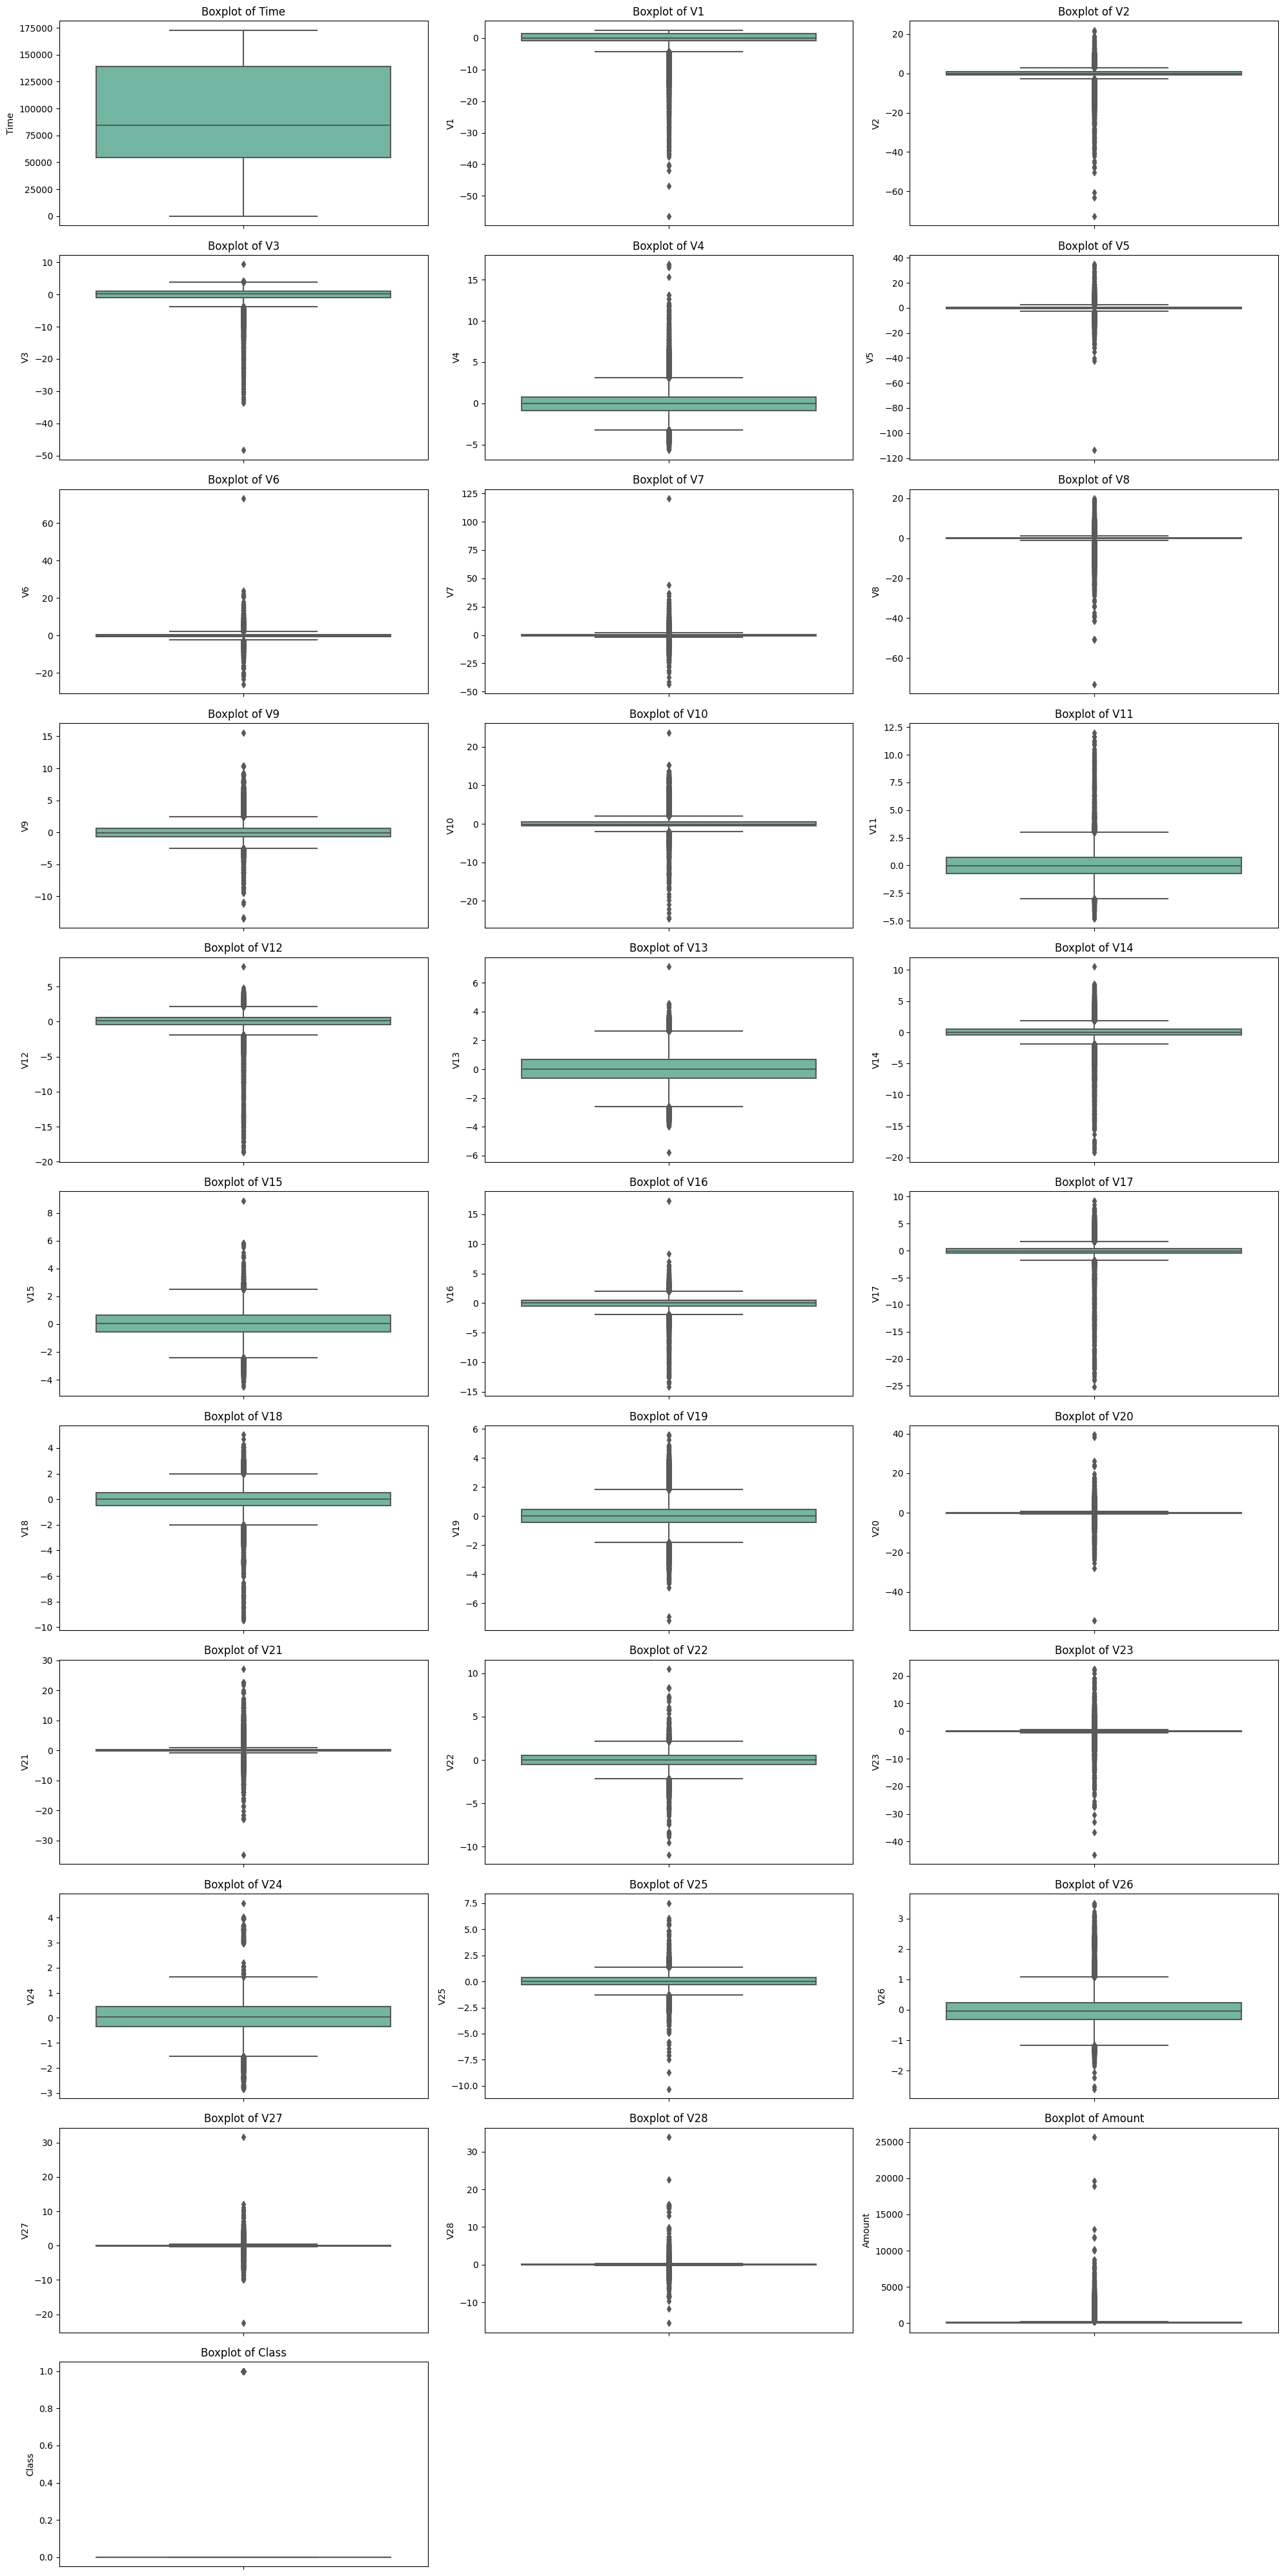

In [19]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)  
    sns.boxplot(data=df, y=col, palette="Set2")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


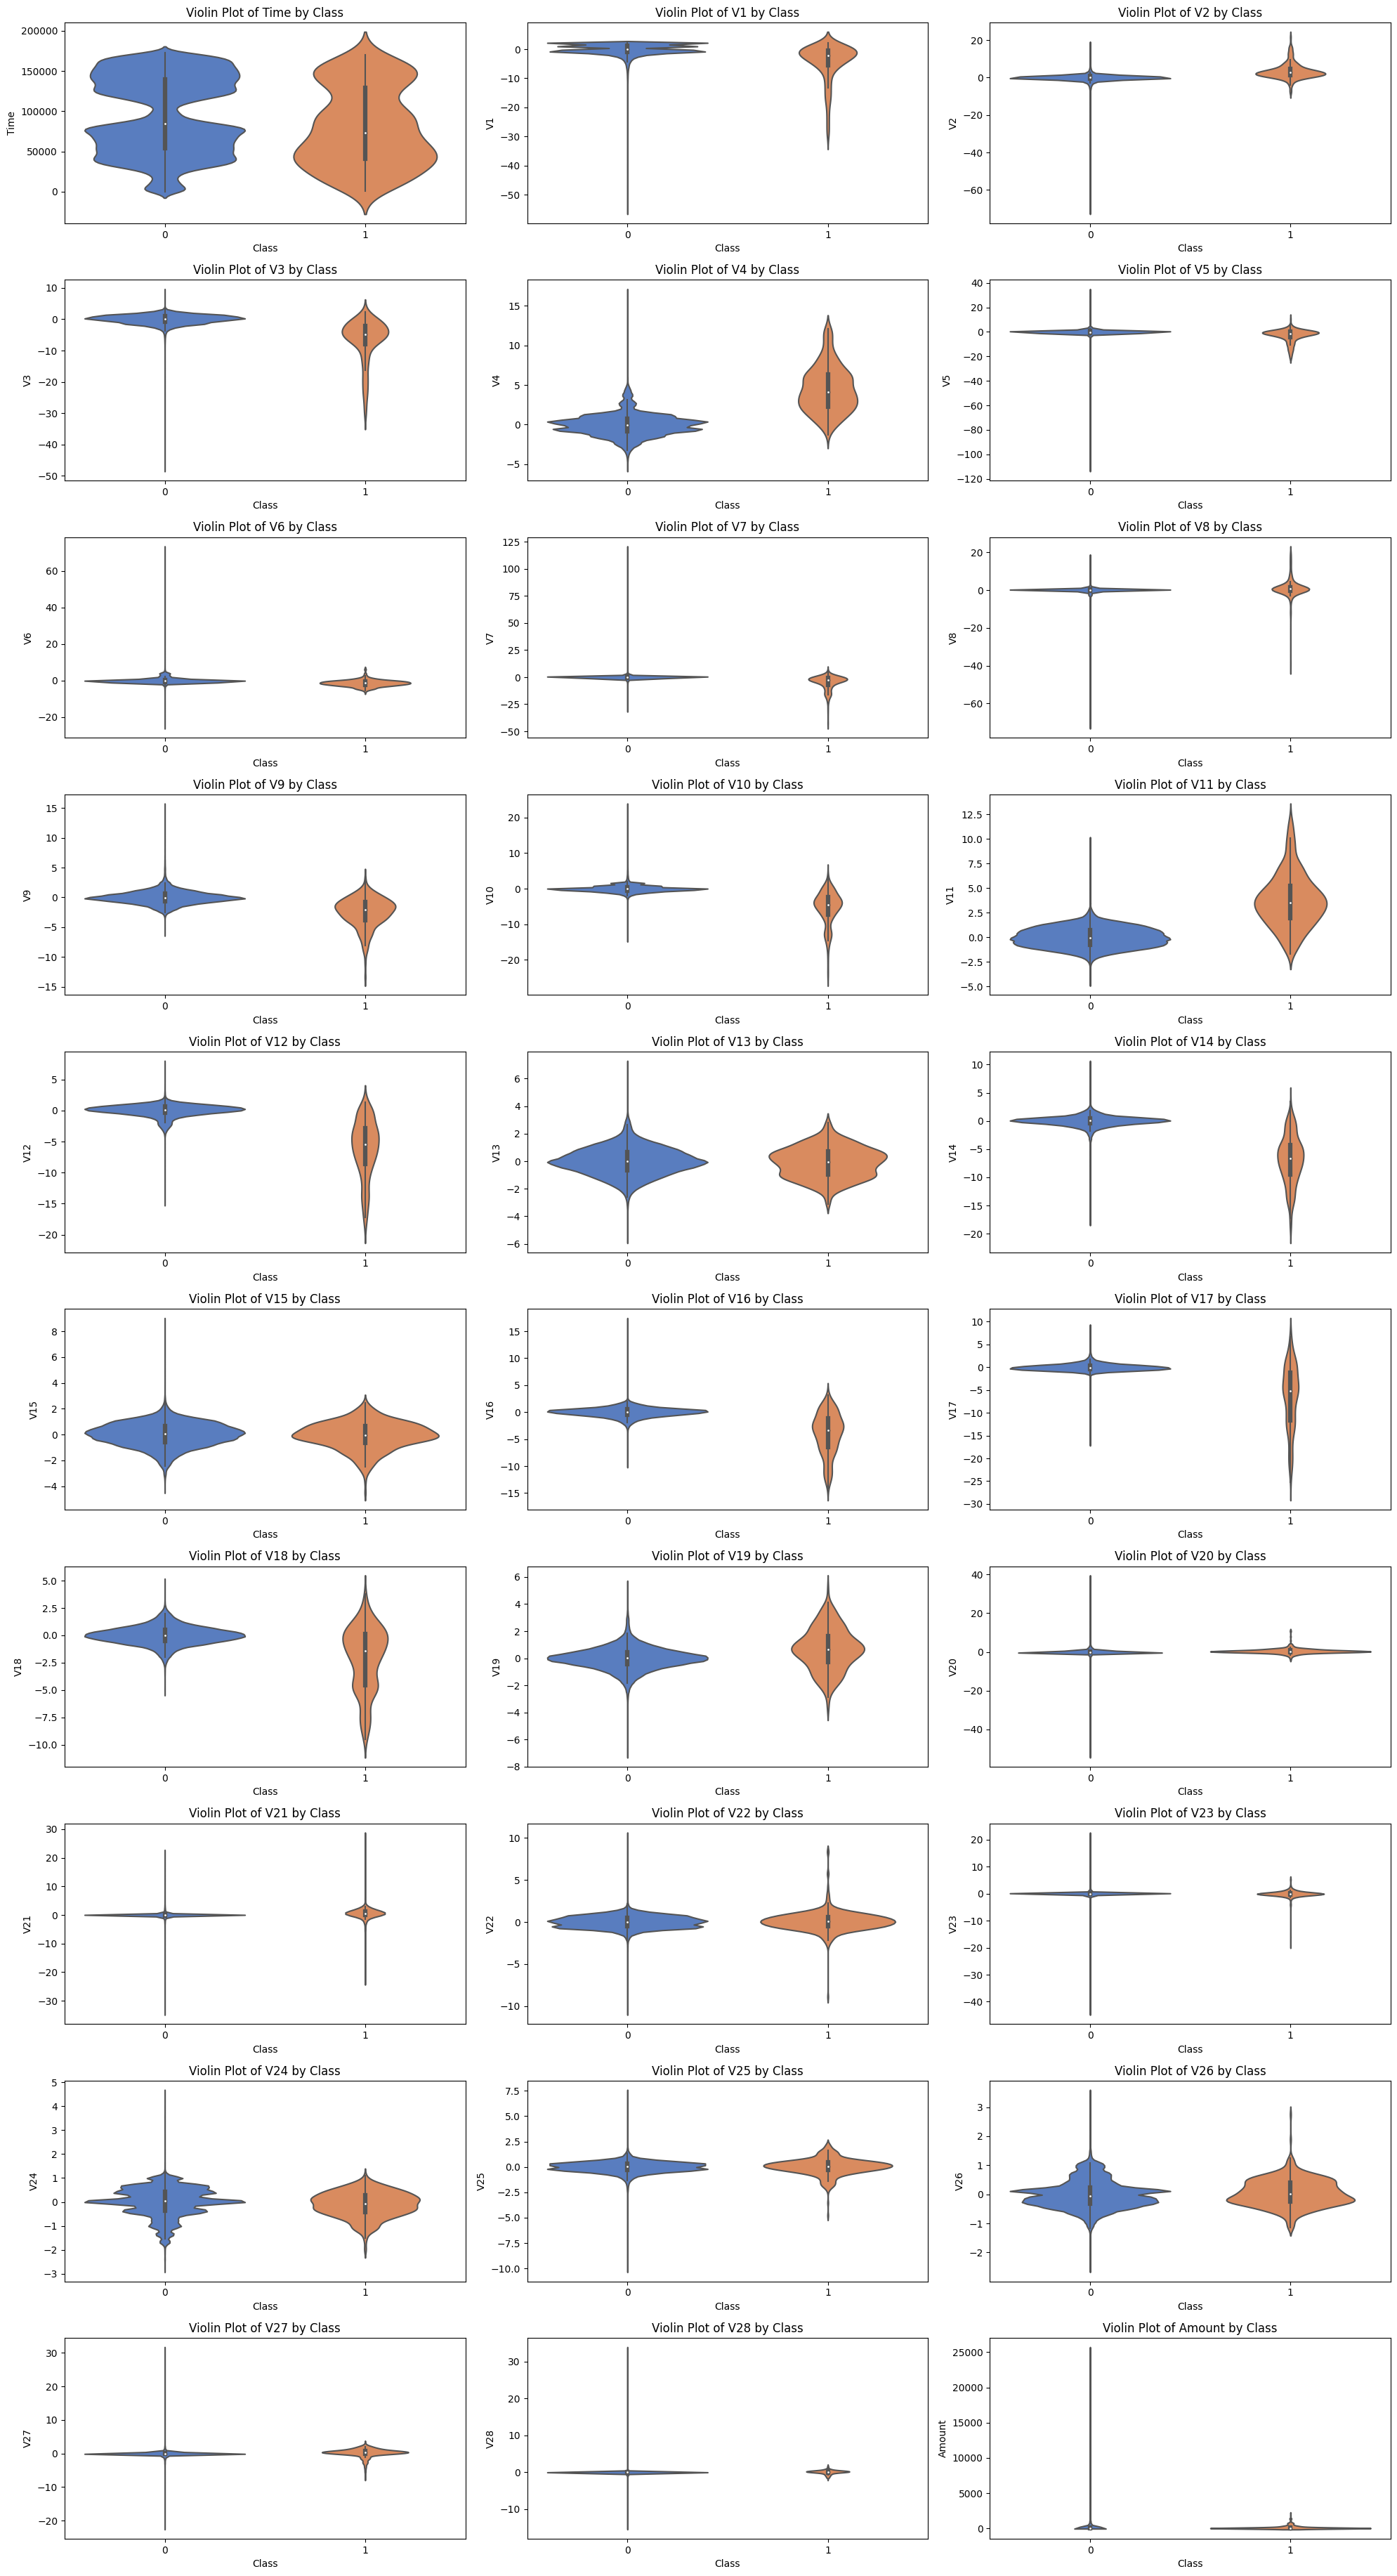

In [20]:
plt.figure(figsize=(20, 40))

for i, col in enumerate(numeric_cols, 1):
    if col != "Class":
        plt.subplot(len(numeric_cols)//3 + 1, 3, i)
        sns.violinplot(data=df, x="Class", y=col, palette="muted", split=True)
        plt.title(f"Violin Plot of {col} by Class")

plt.tight_layout()
plt.show()


#### No Outliers is Real Values i will keep it

# ****Data Analysis****

In [21]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

###  Time 

In [22]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

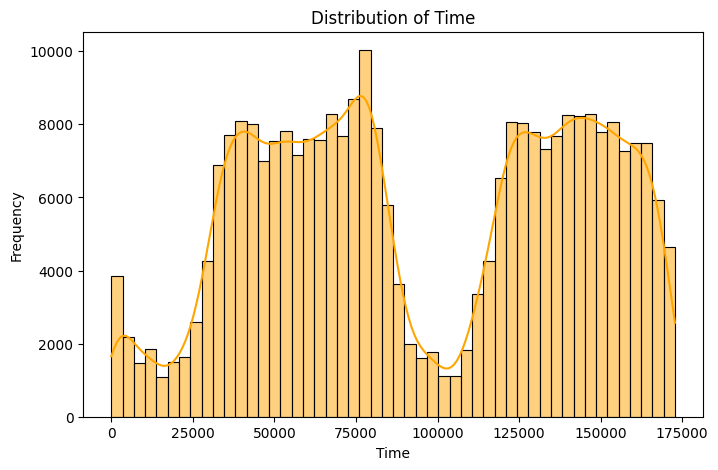

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50, kde=True, color="orange")
plt.title("Distribution of Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

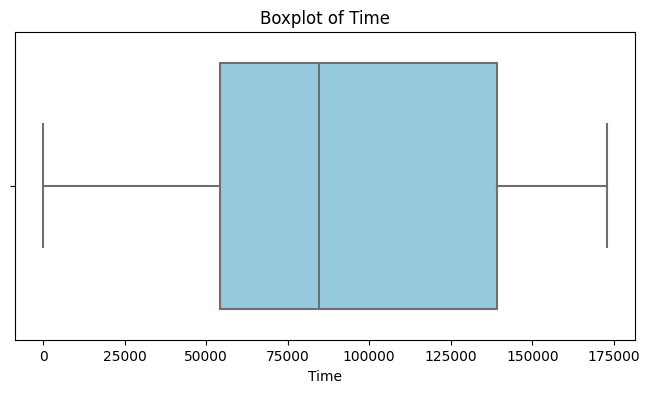

In [24]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Time"], color="skyblue")
plt.title("Boxplot of Time")
plt.xlabel("Time")
plt.show()

# V1--V28

In [25]:
def analyze_feature(df, column):
    
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    sns.histplot(df[column], bins=50, kde=True, ax=axes[0], color="orange")
    axes[0].set_title(f"Distribution of {column}")
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[1], color="skyblue")
    axes[1].set_title(f"Boxplot of {column}")
    
    # Violinplot
    sns.violinplot(x=df[column], ax=axes[2], color="lightgreen")
    axes[2].set_title(f"Violin Plot of {column}")
    
    plt.tight_layout()
    plt.show()


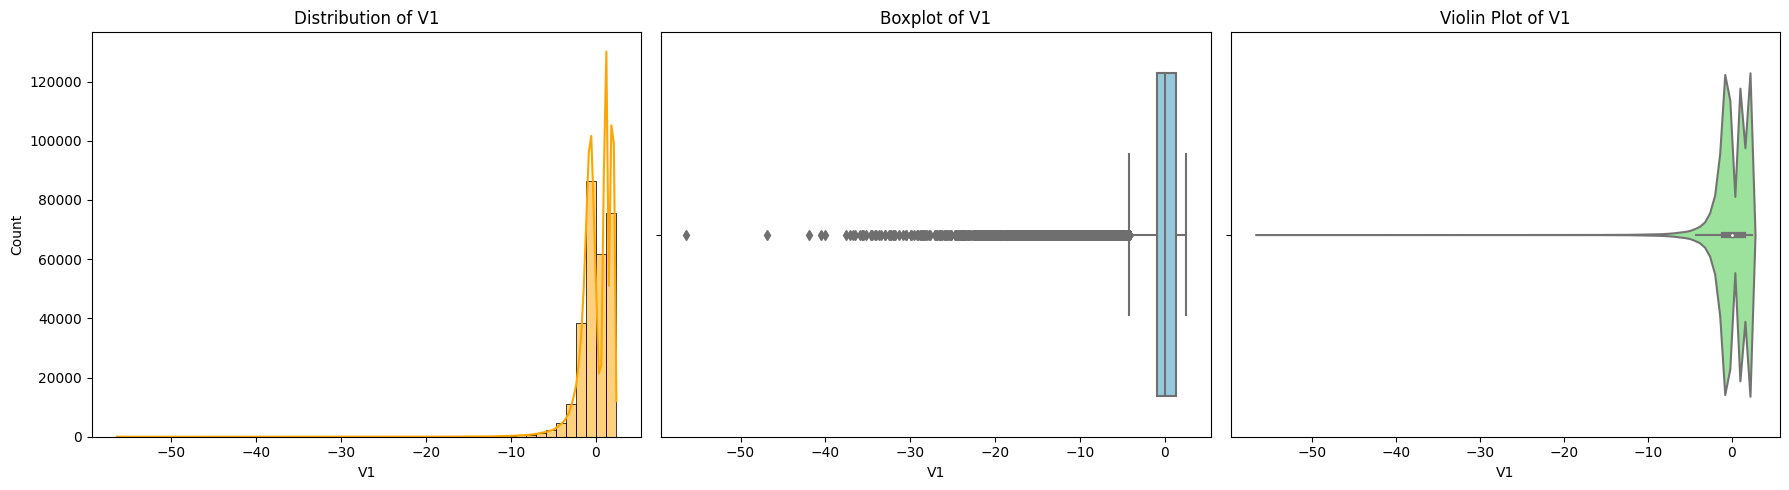

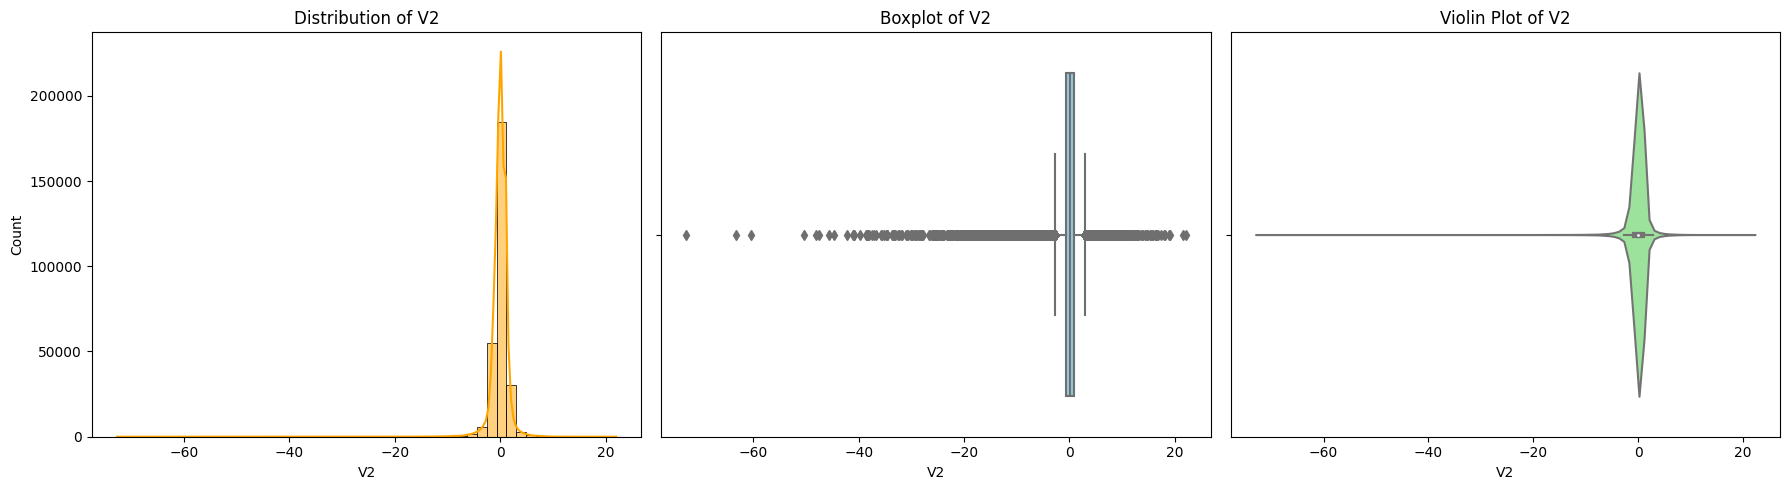

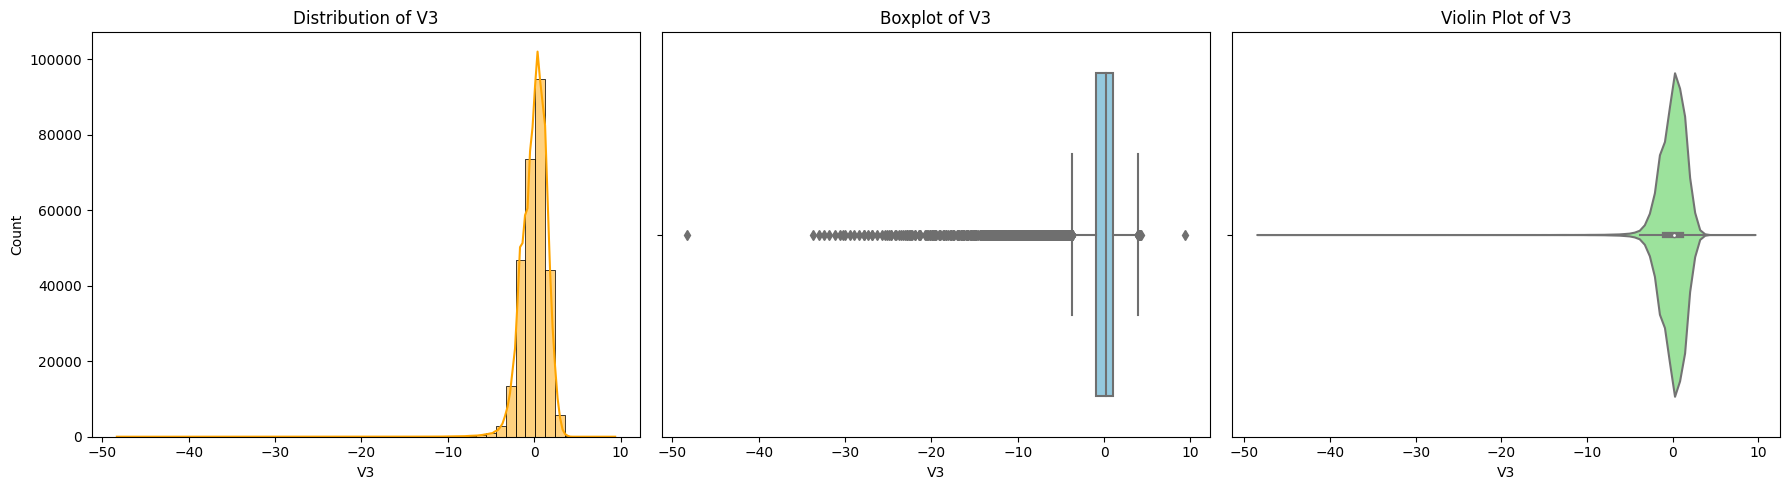

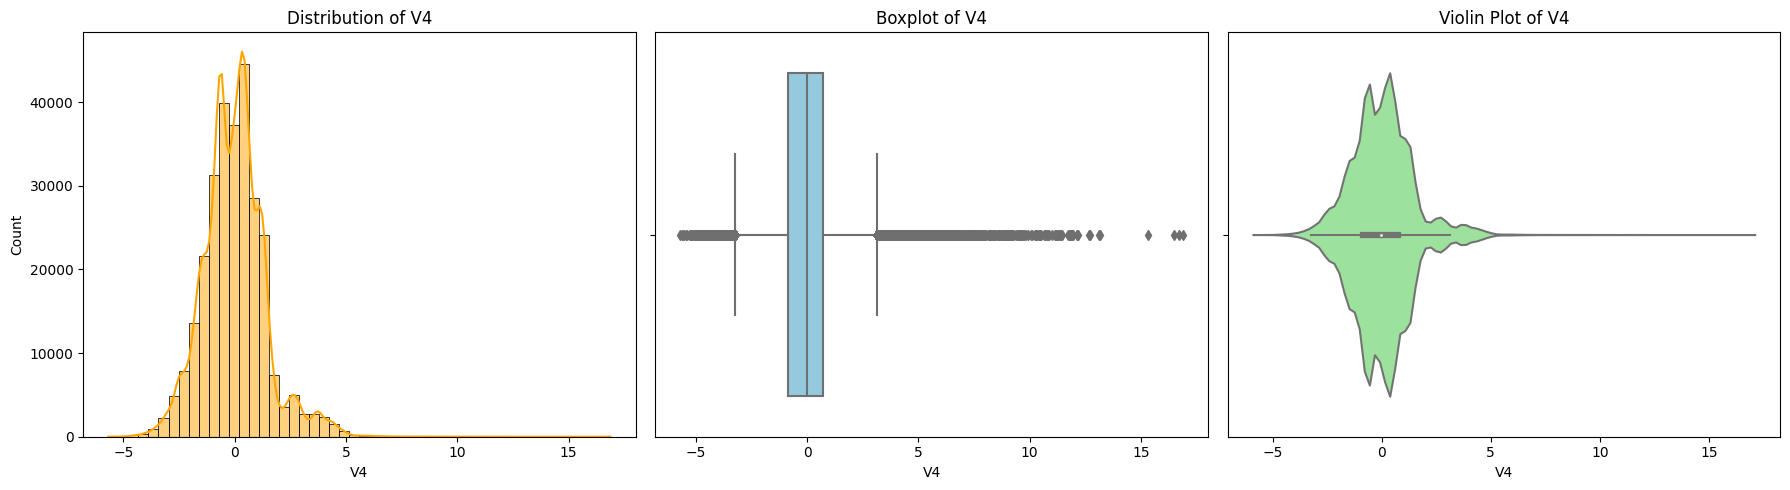

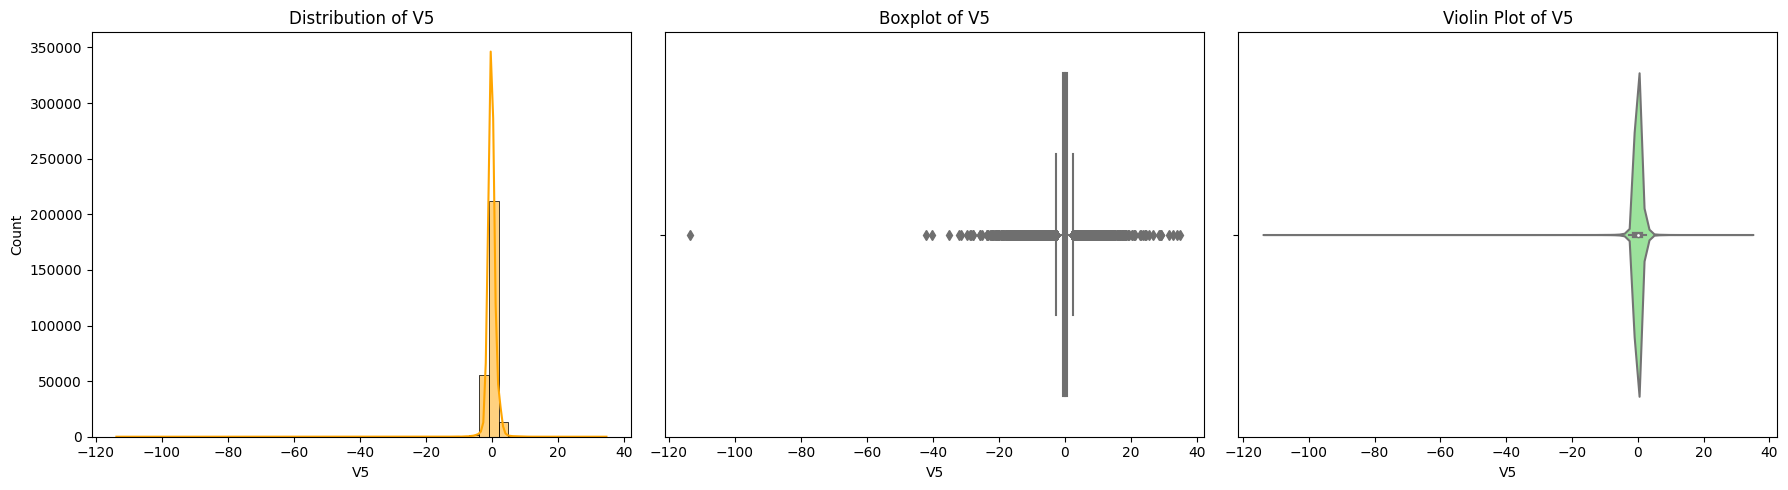

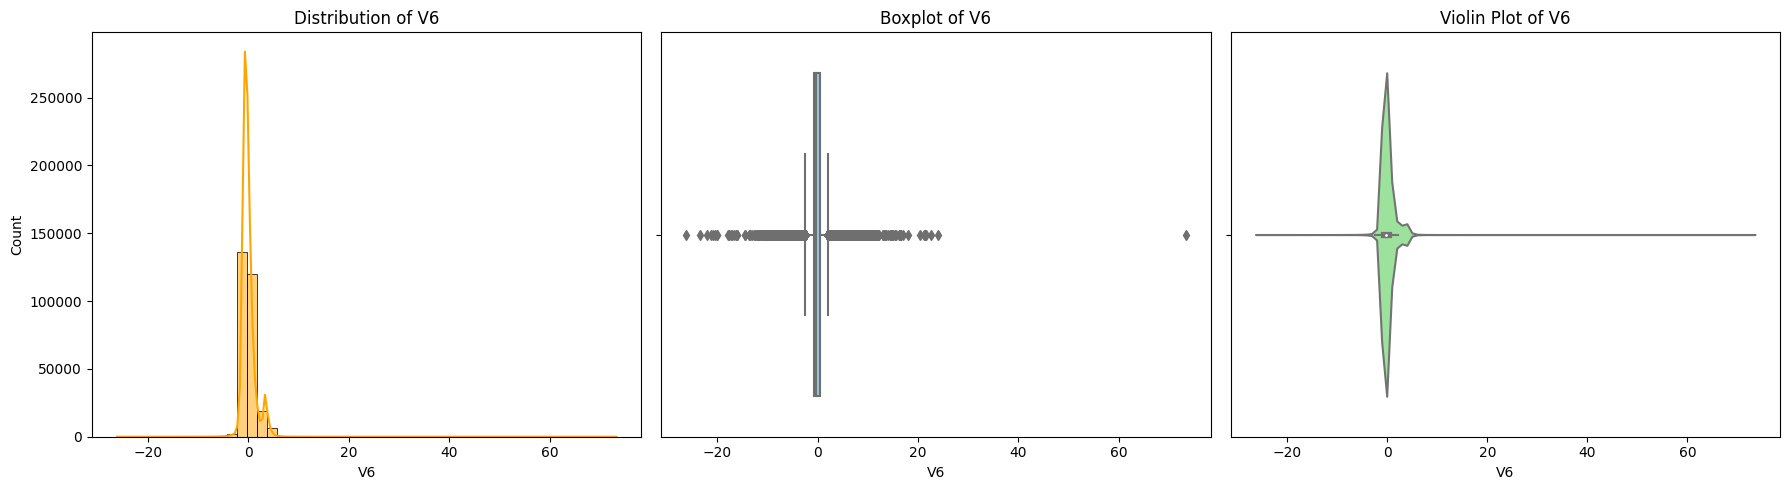

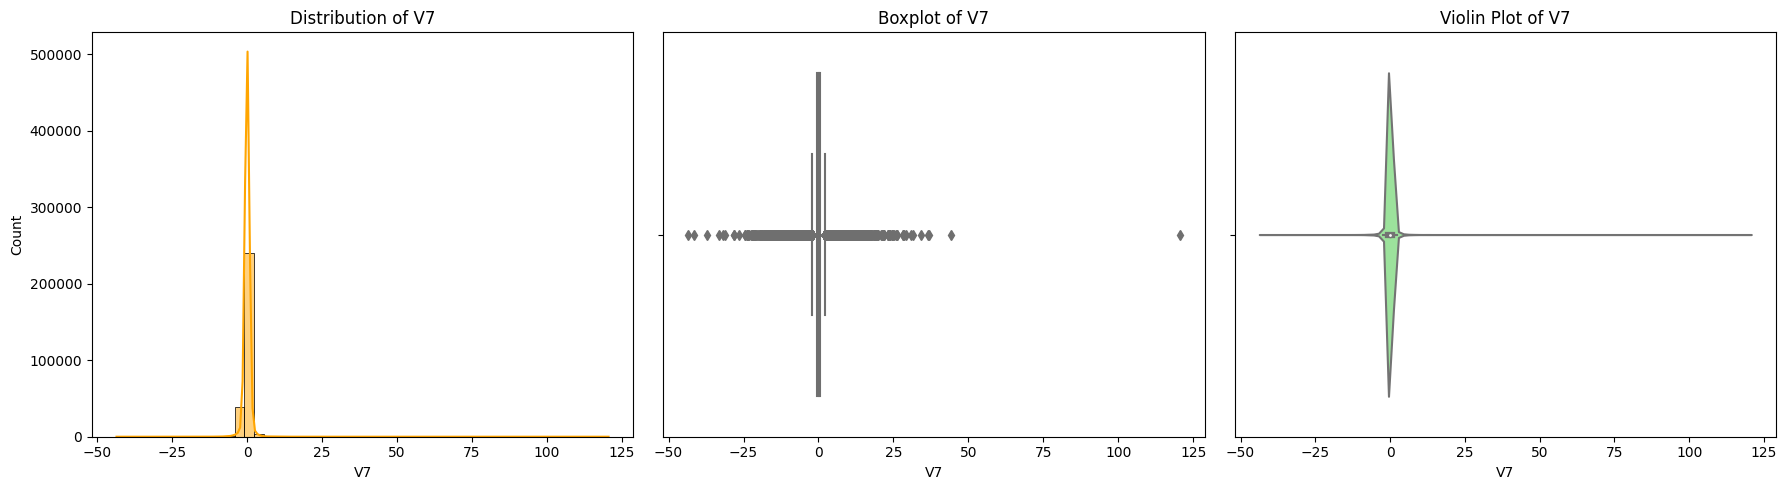

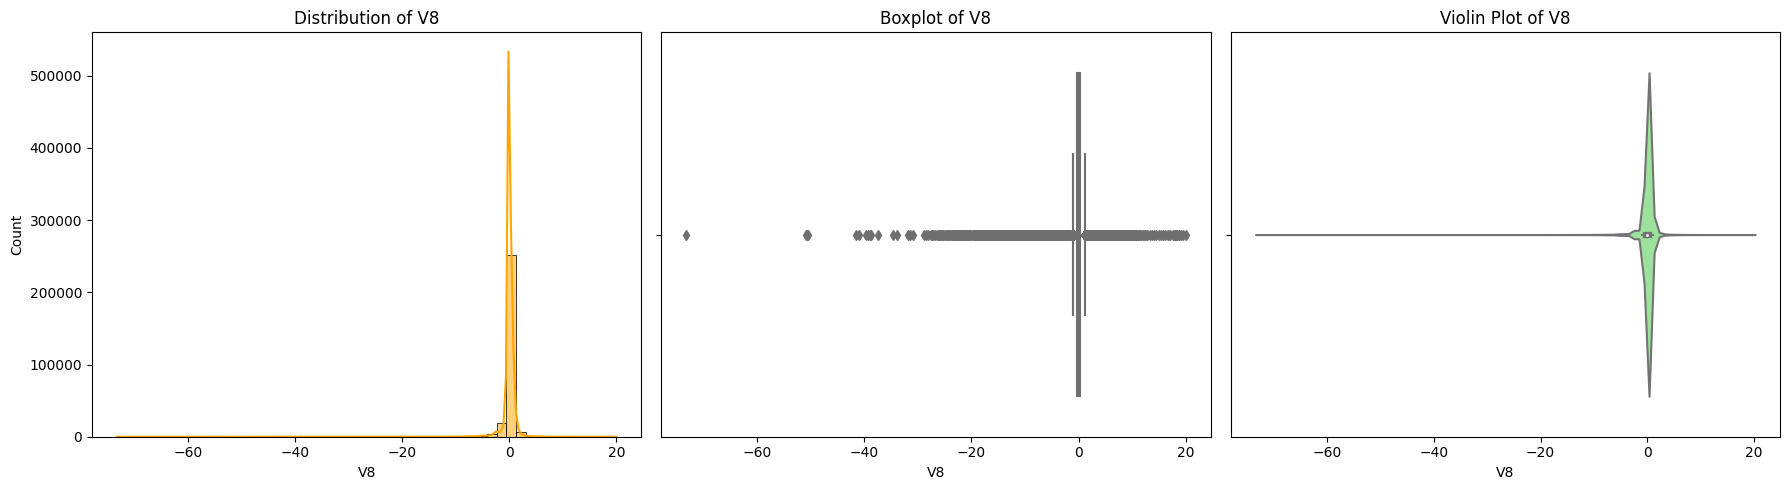

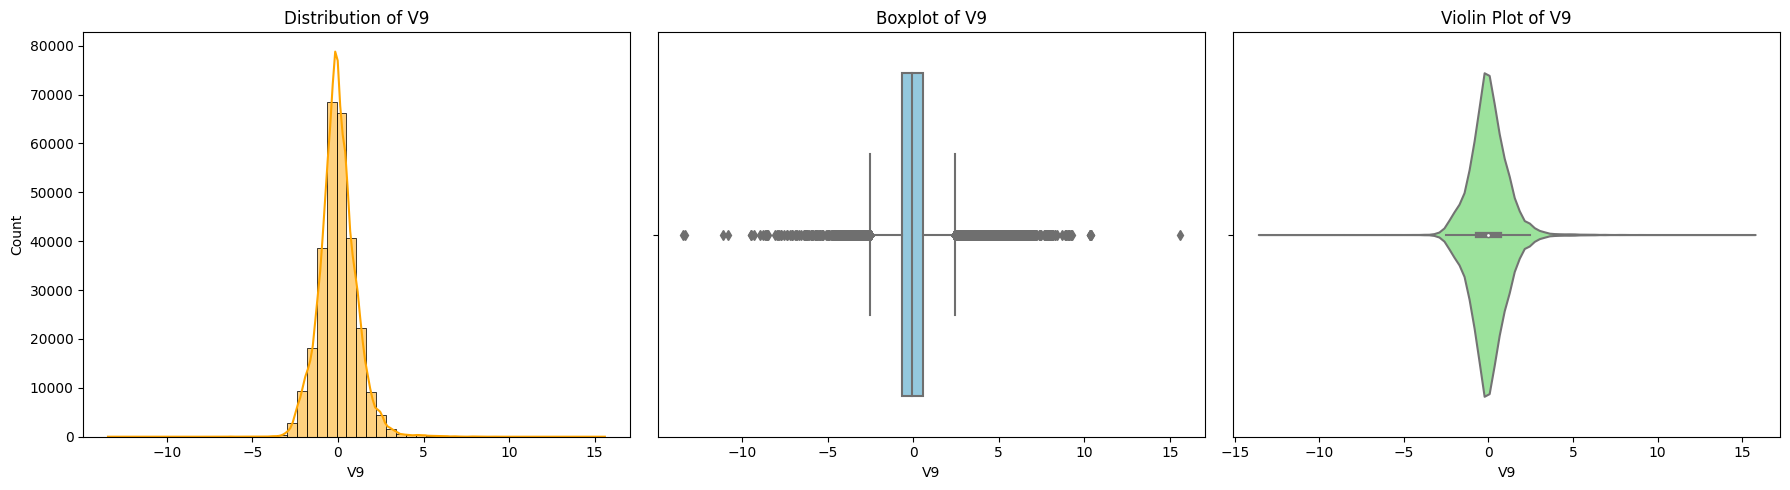

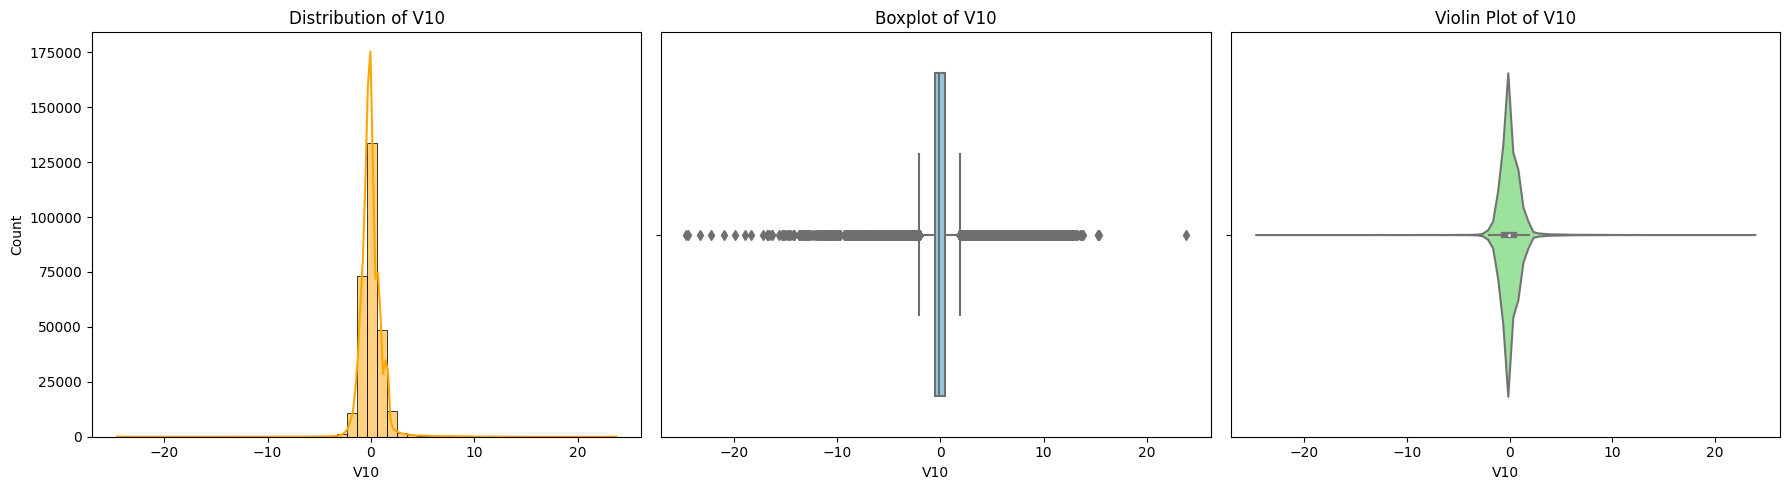

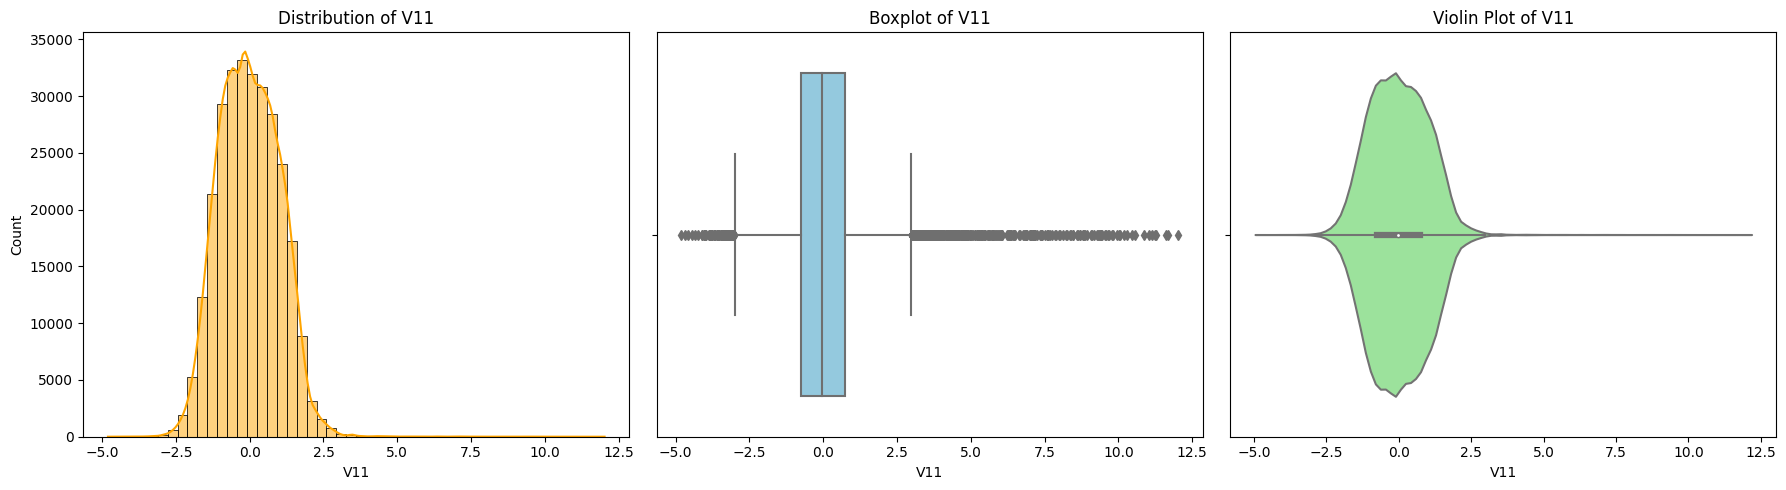

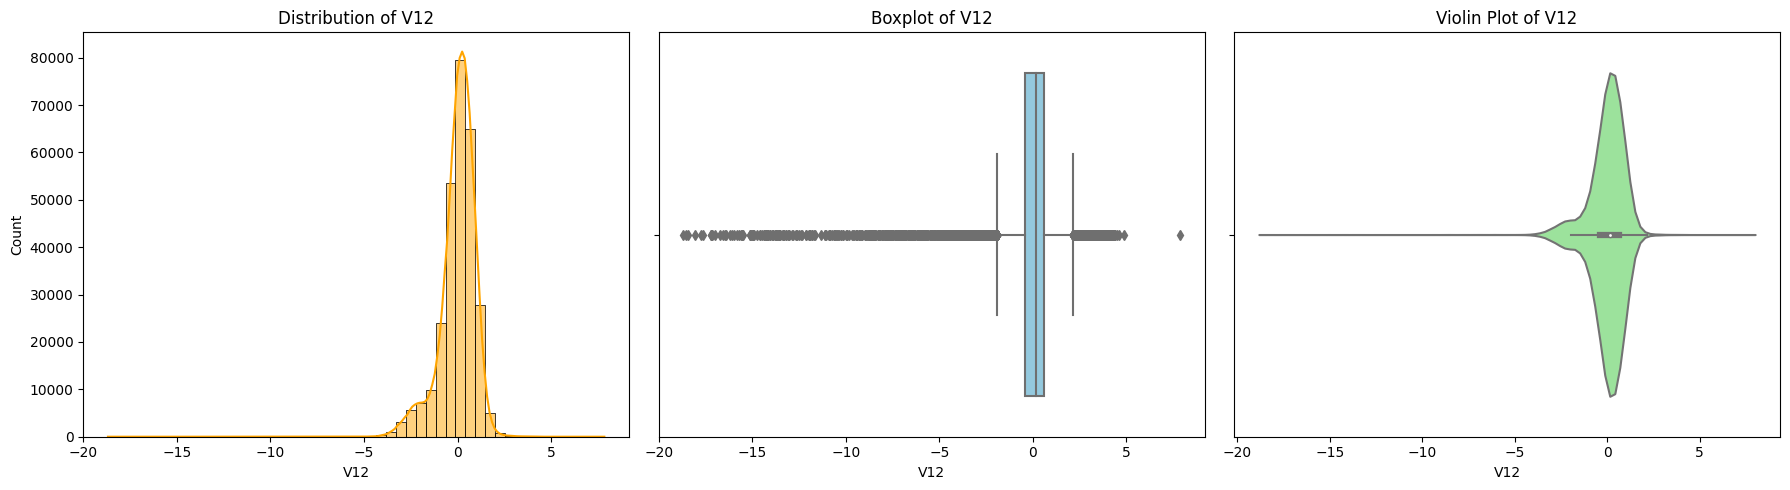

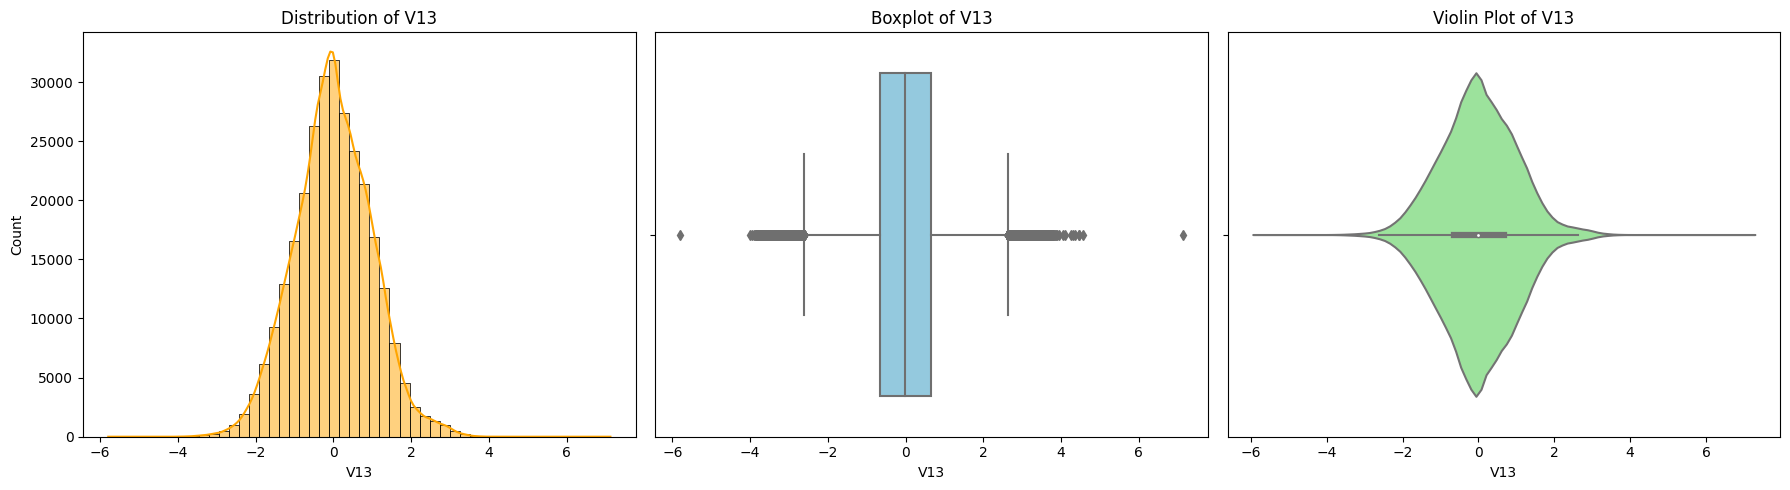

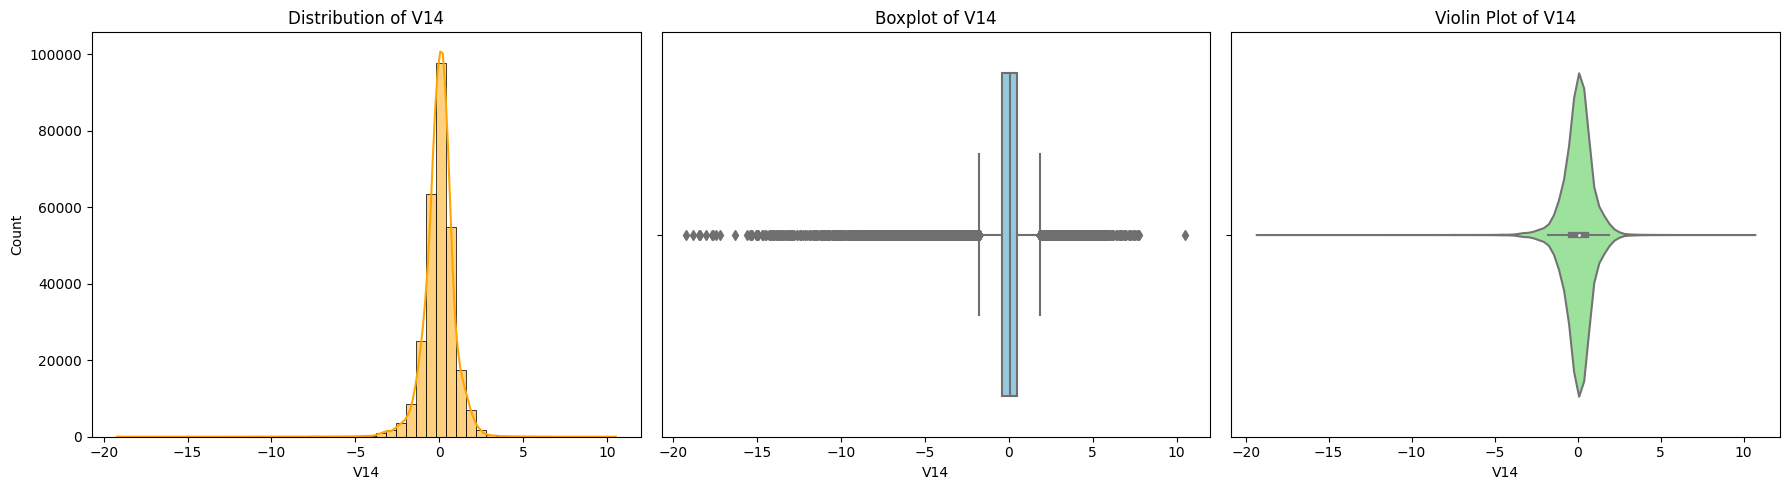

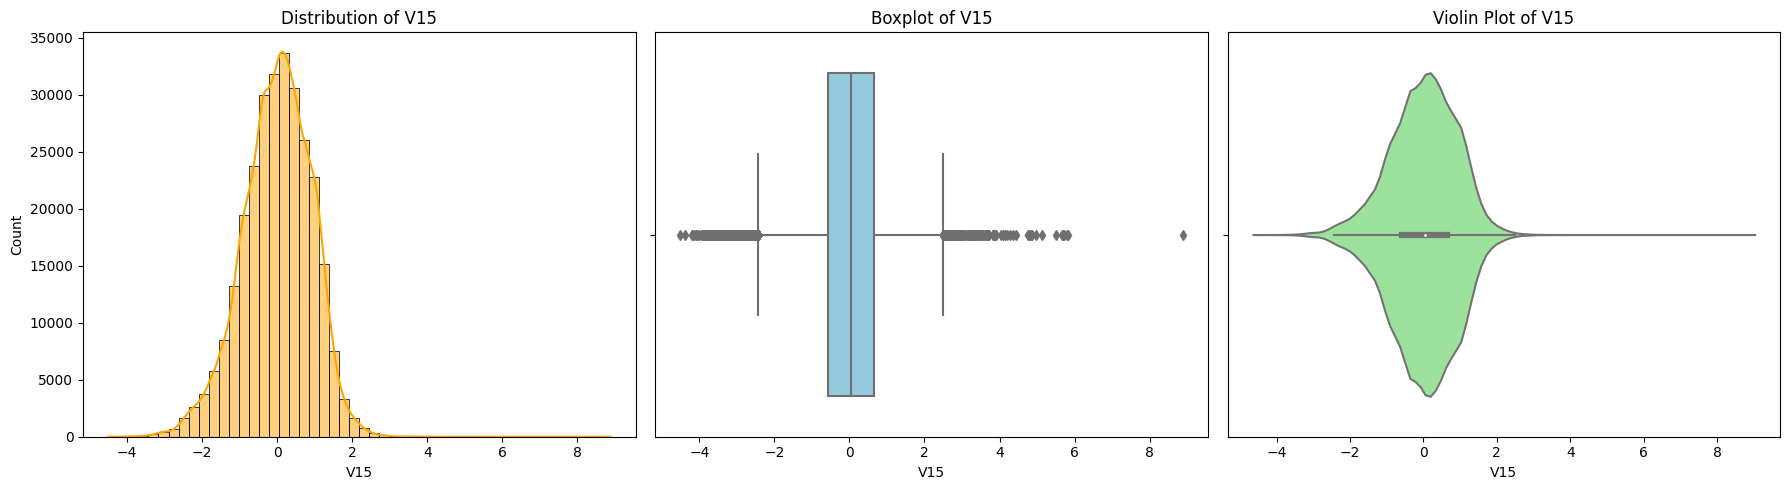

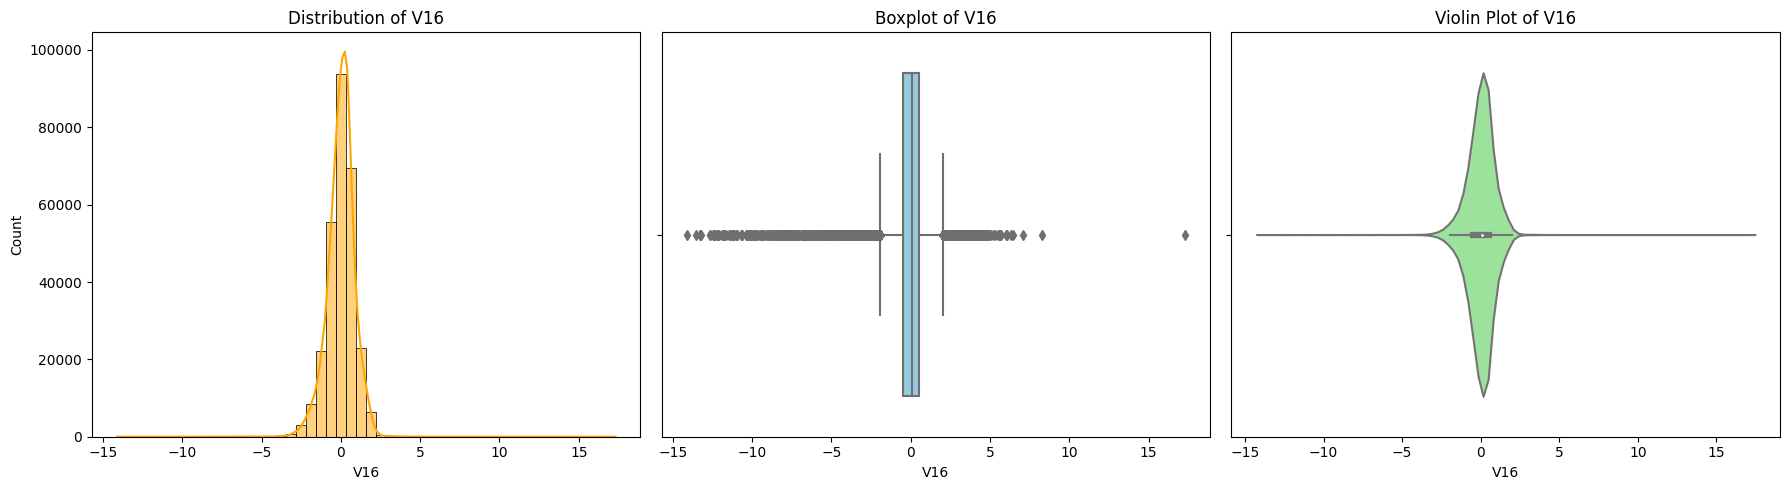

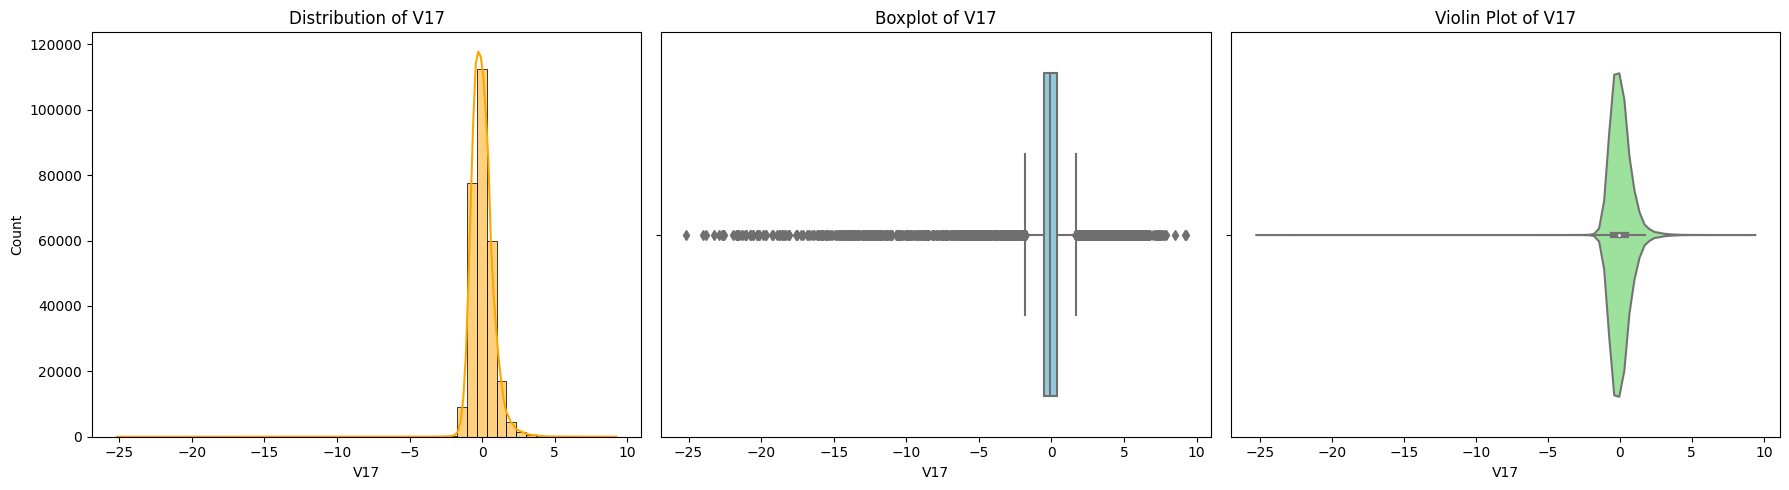

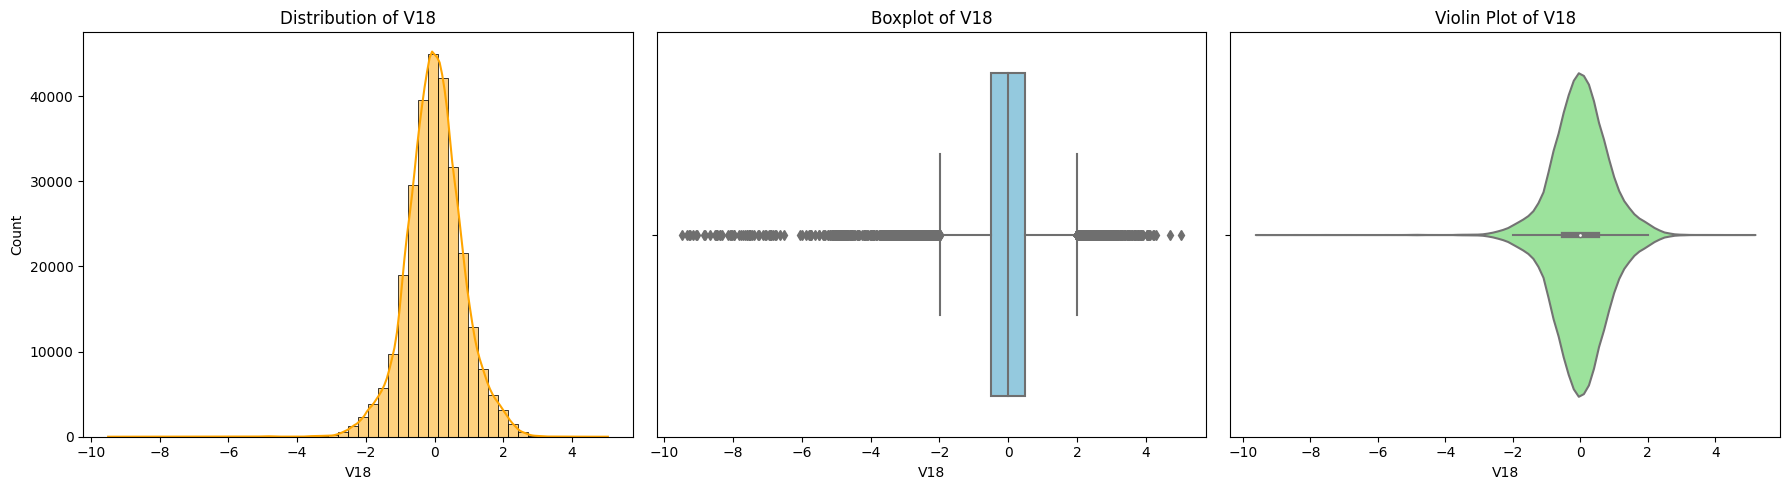

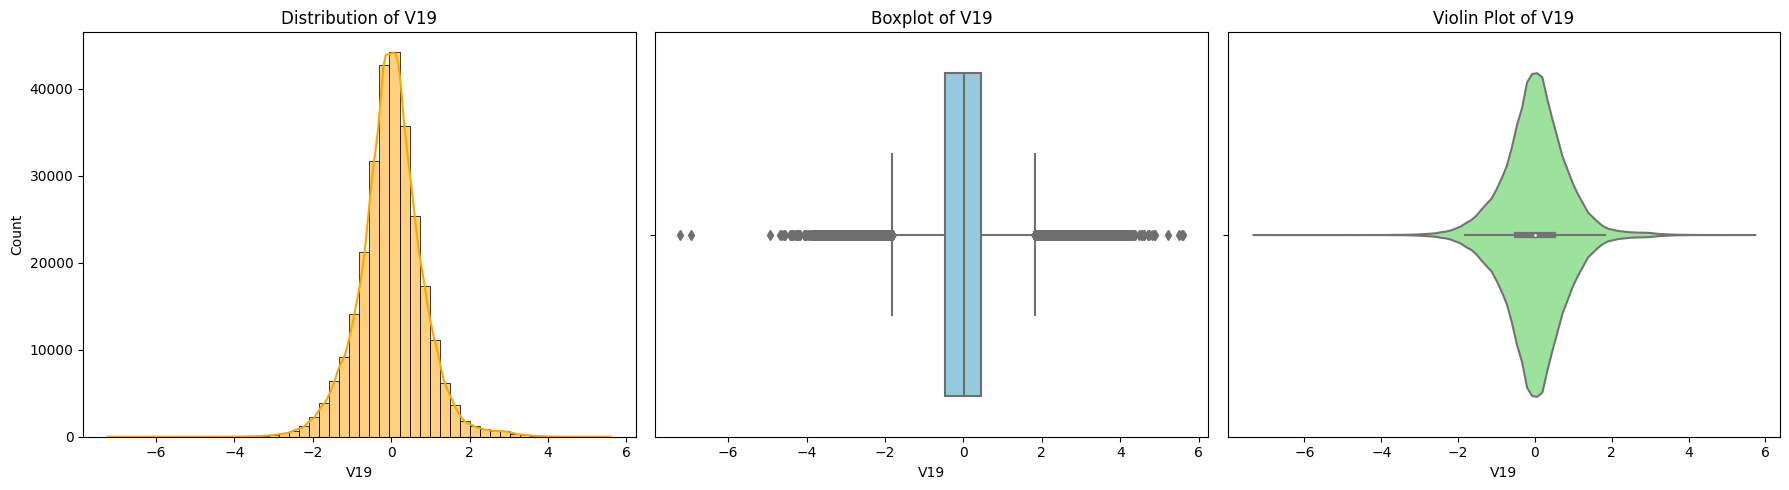

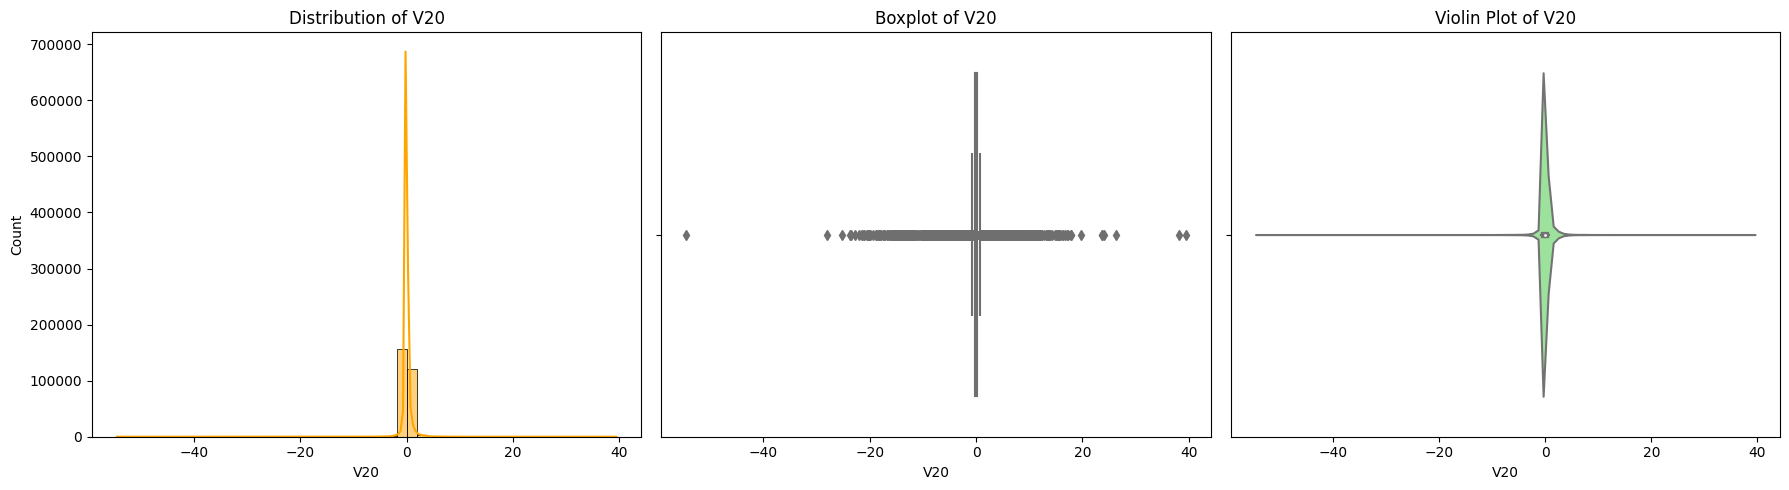

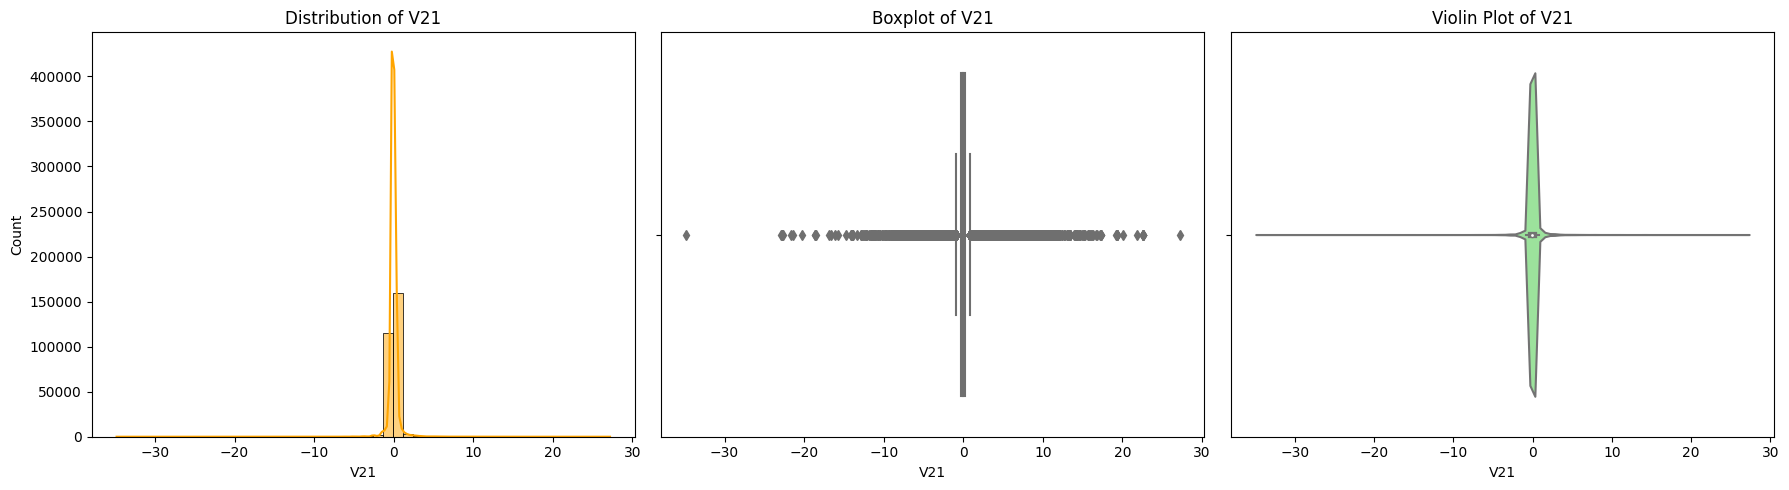

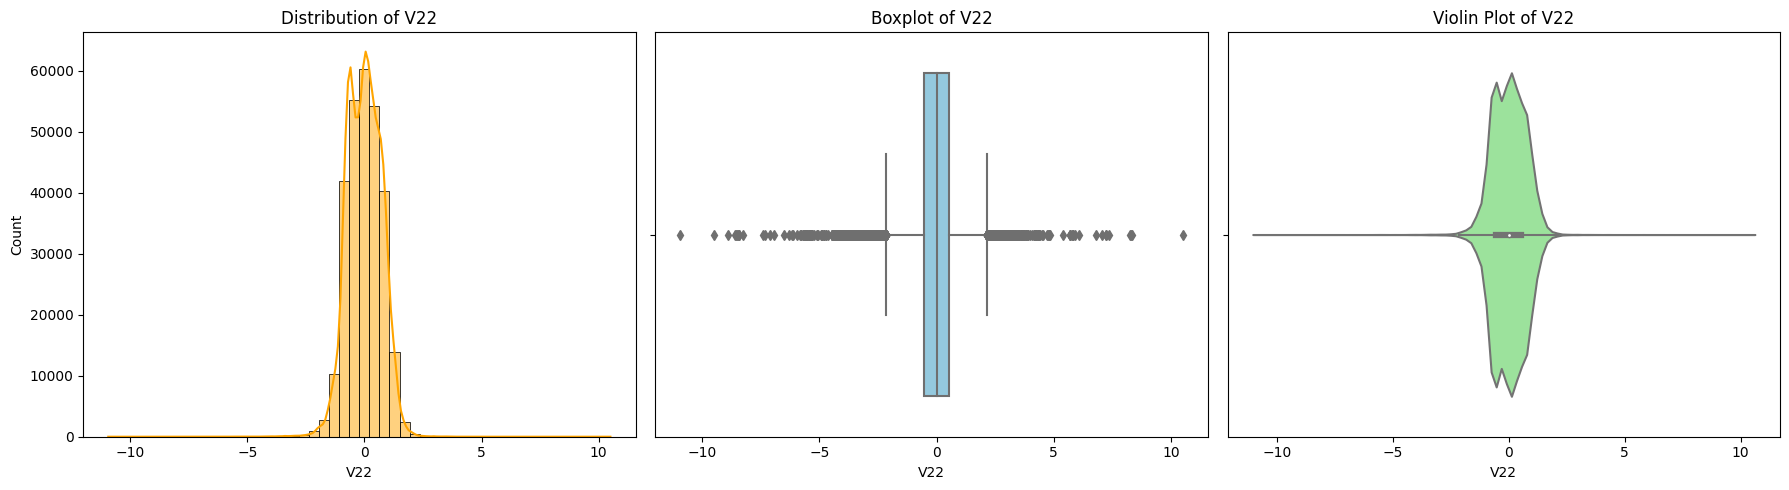

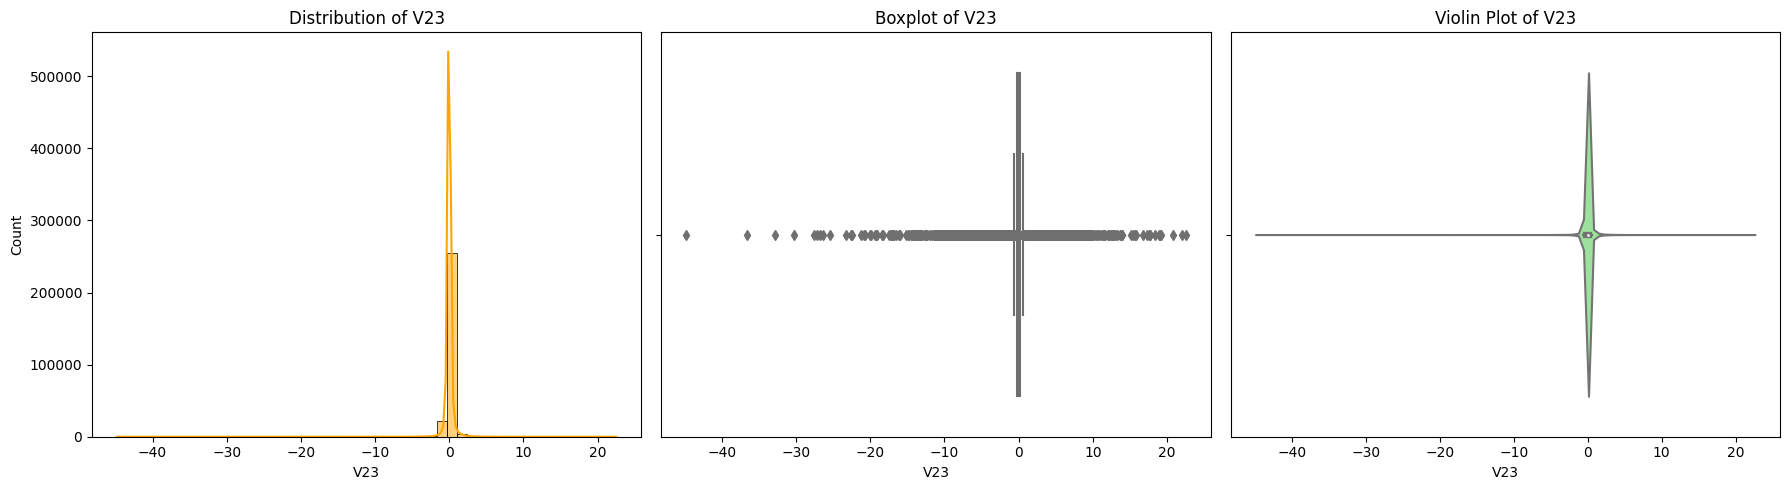

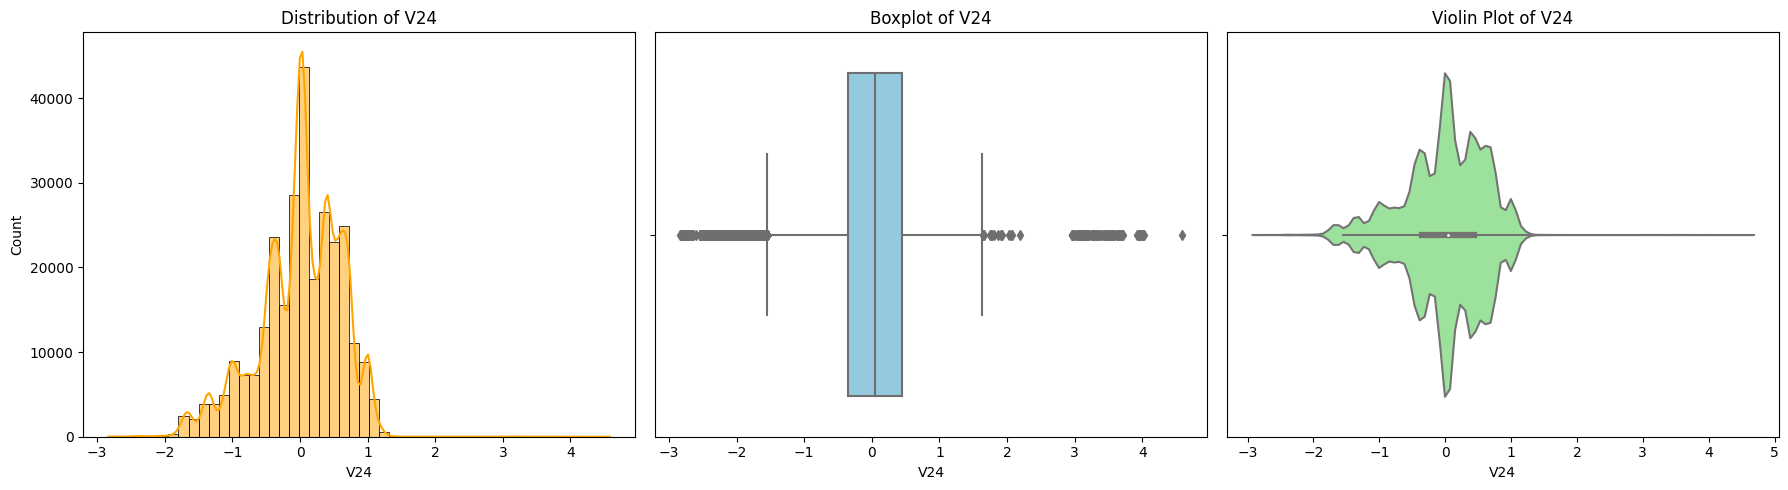

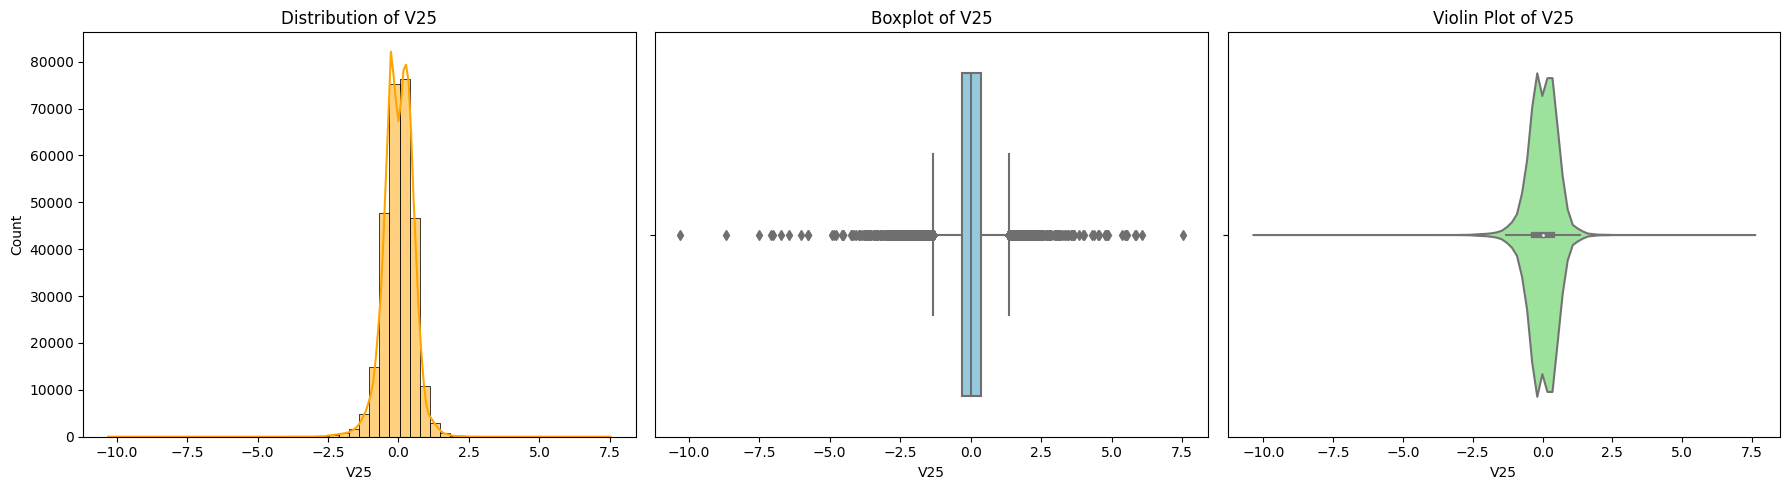

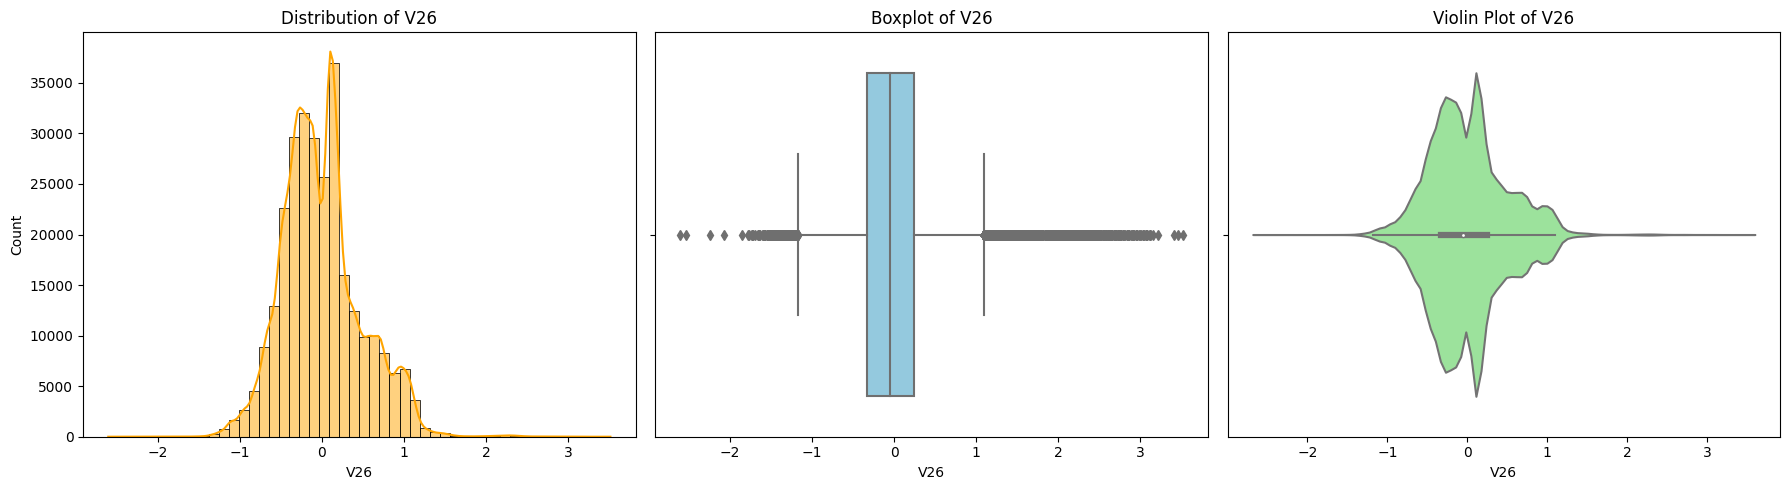

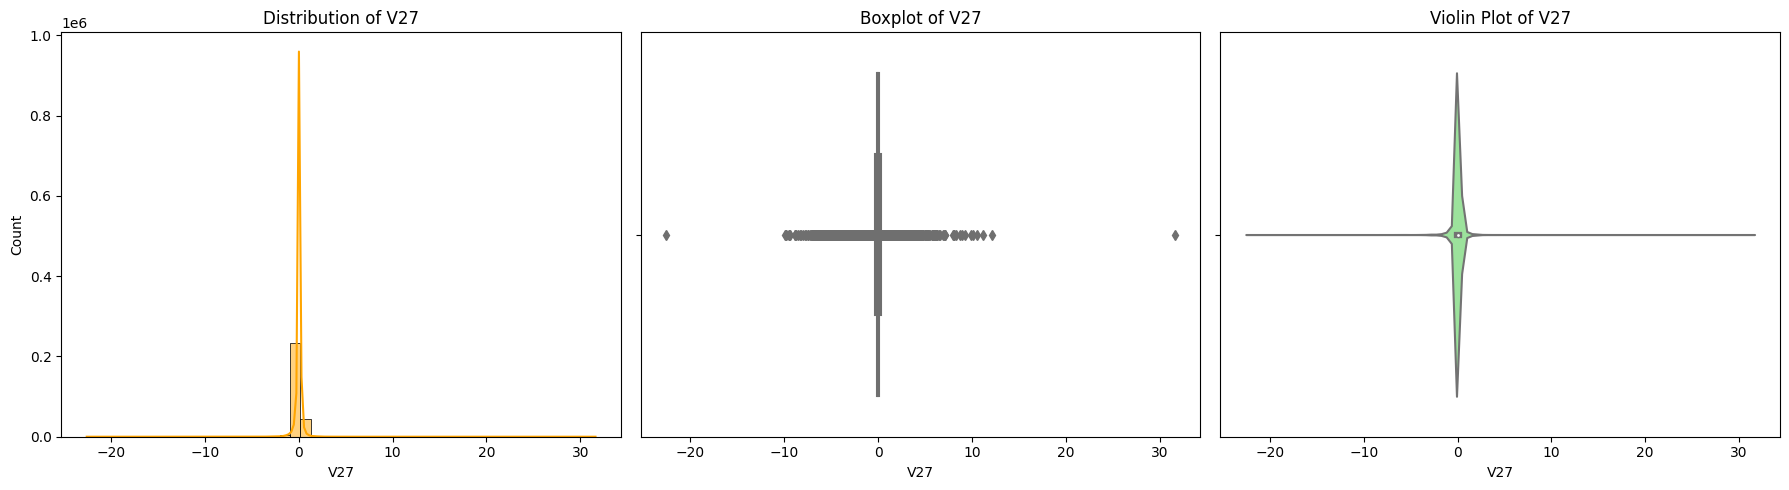

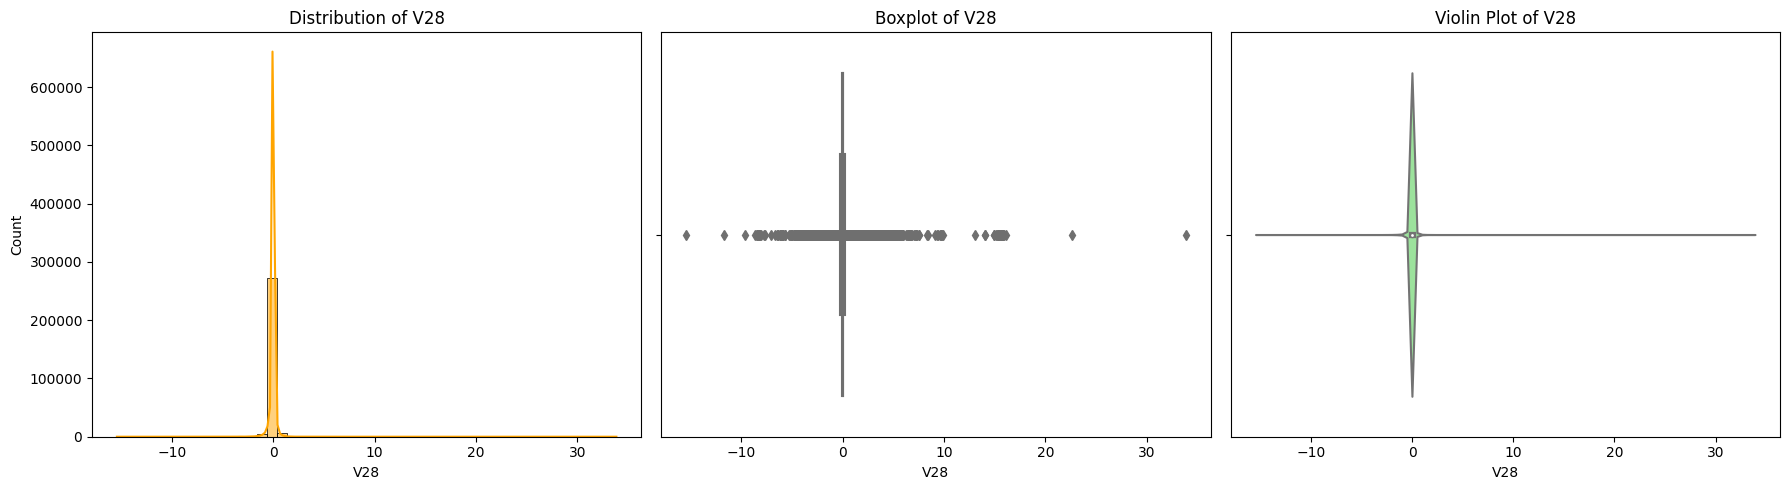

In [26]:
features = [f"V{i}" for i in range(1,29)]

for col in features:
    analyze_feature(df, col)

### Amount

In [27]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

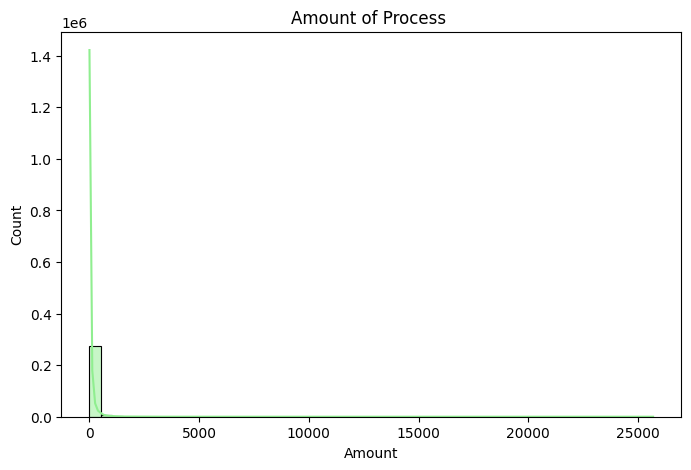

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True, color="lightgreen")
plt.title("Amount of Process ")
plt.show()

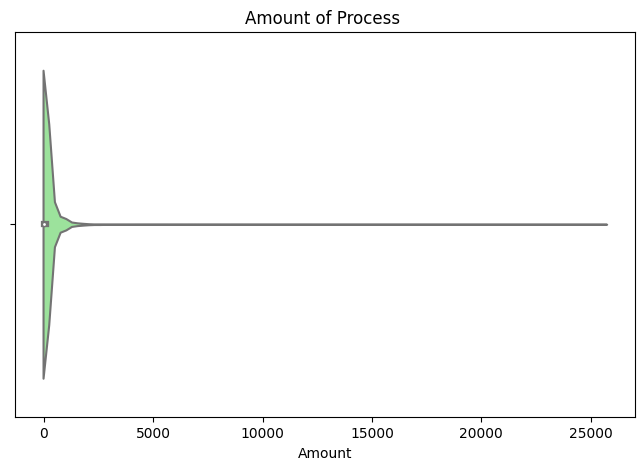

In [29]:
plt.figure(figsize=(8,5))
sns.violinplot(x=df["Amount"], color="lightgreen")
plt.title("Amount of Process ")
plt.show()

### Class  

In [30]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

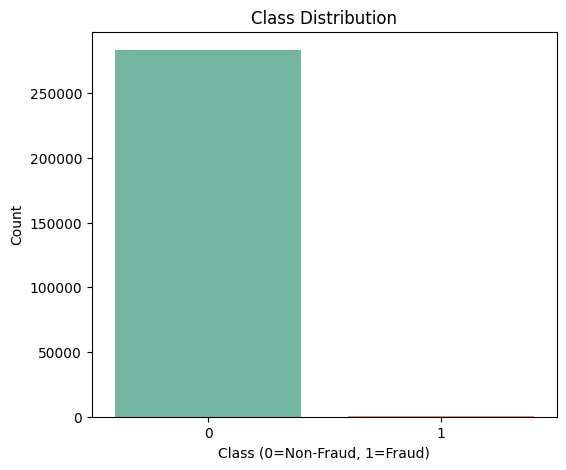

Fraud Percentage: 0.1667%


In [31]:
plt.figure(figsize=(6,5))
sns.countplot(x="Class", data=df, palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Class (0=Non-Fraud, 1=Fraud)")
plt.ylabel("Count")
plt.show()

fraud_percentage = df["Class"].mean() * 100
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

# Bivariate Analysis

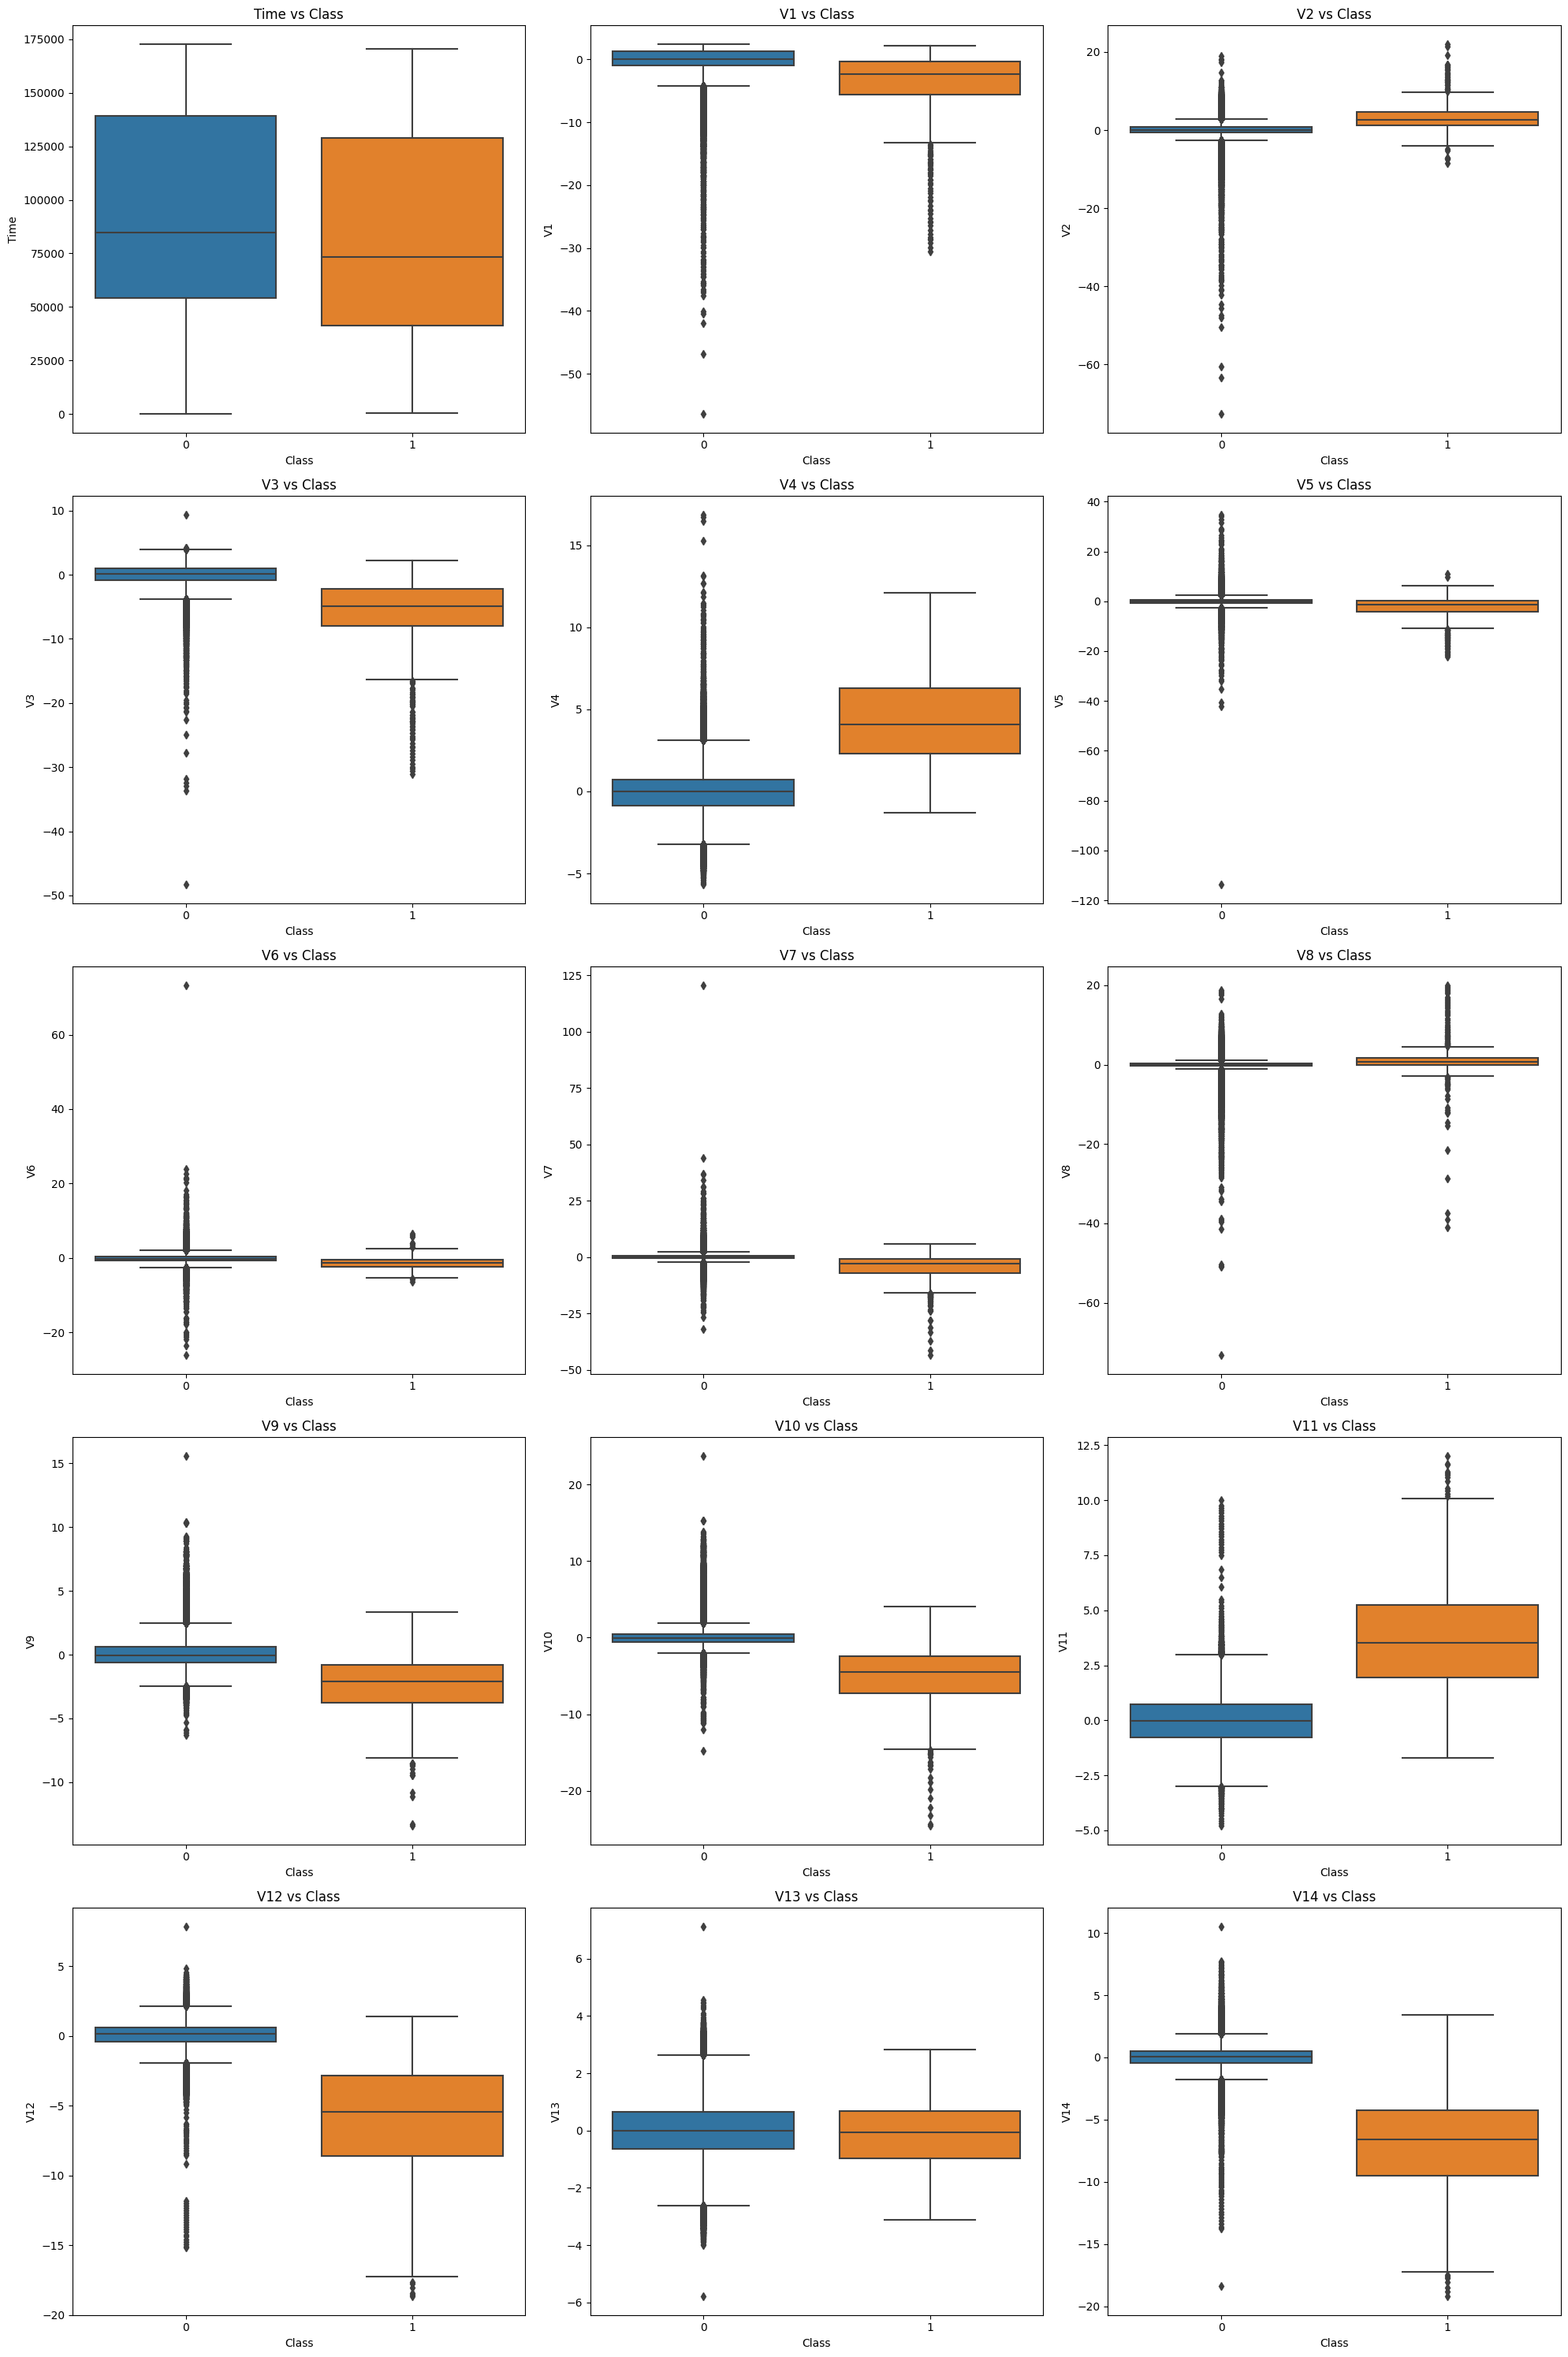

In [32]:
numeric_columns = df.drop(columns=["Class"]).columns  

first_half = numeric_columns[:15]   # Time → V14
second_half = numeric_columns[15:]  # V15 → Amount

plt.figure(figsize=(20, 30))
for i, feature in enumerate(first_half, start=1):
    plt.subplot(5, 3, i)  
    sns.boxplot(x="Class", y=feature, data=df)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Class")
plt.tight_layout()
plt.show()



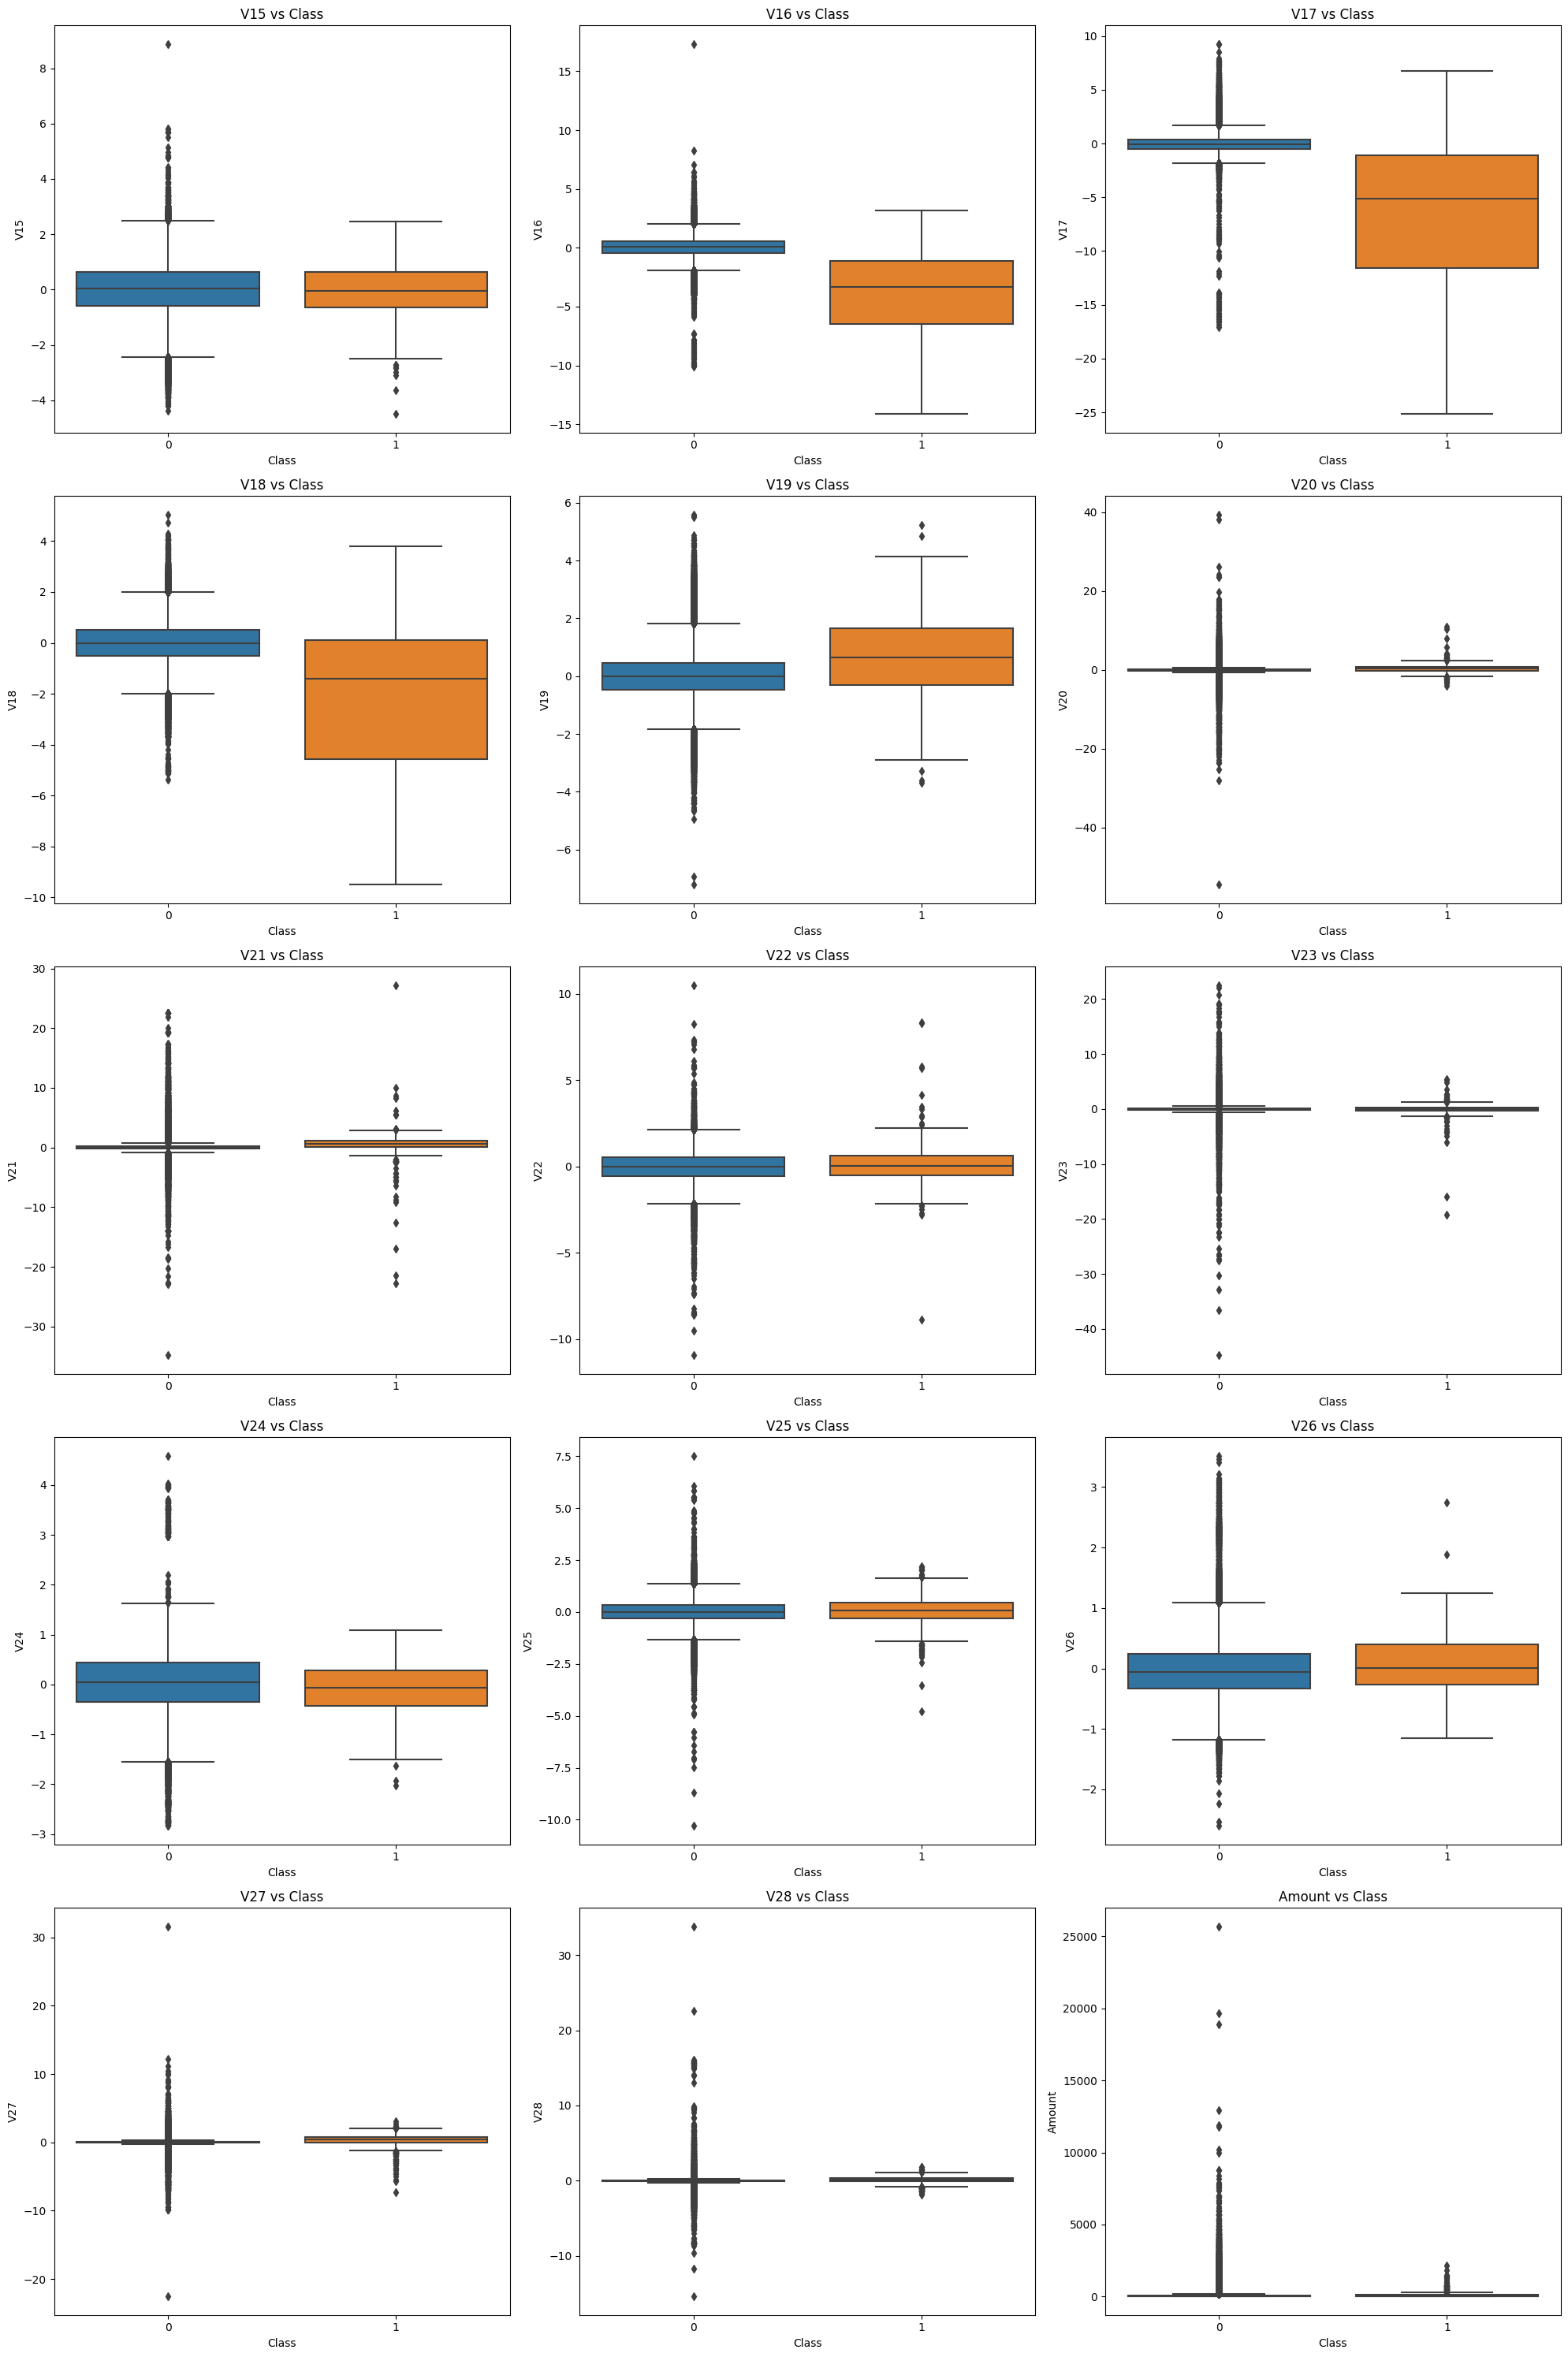

In [33]:

plt.figure(figsize=(20, 30))
for i, feature in enumerate(second_half, start=1):
    plt.subplot(5, 3, i)  
    sns.boxplot(x="Class", y=feature, data=df)
    plt.xlabel("Class")
    plt.ylabel(feature)
    plt.title(f"{feature} vs Class")
plt.tight_layout()
plt.show()

# HeatMap

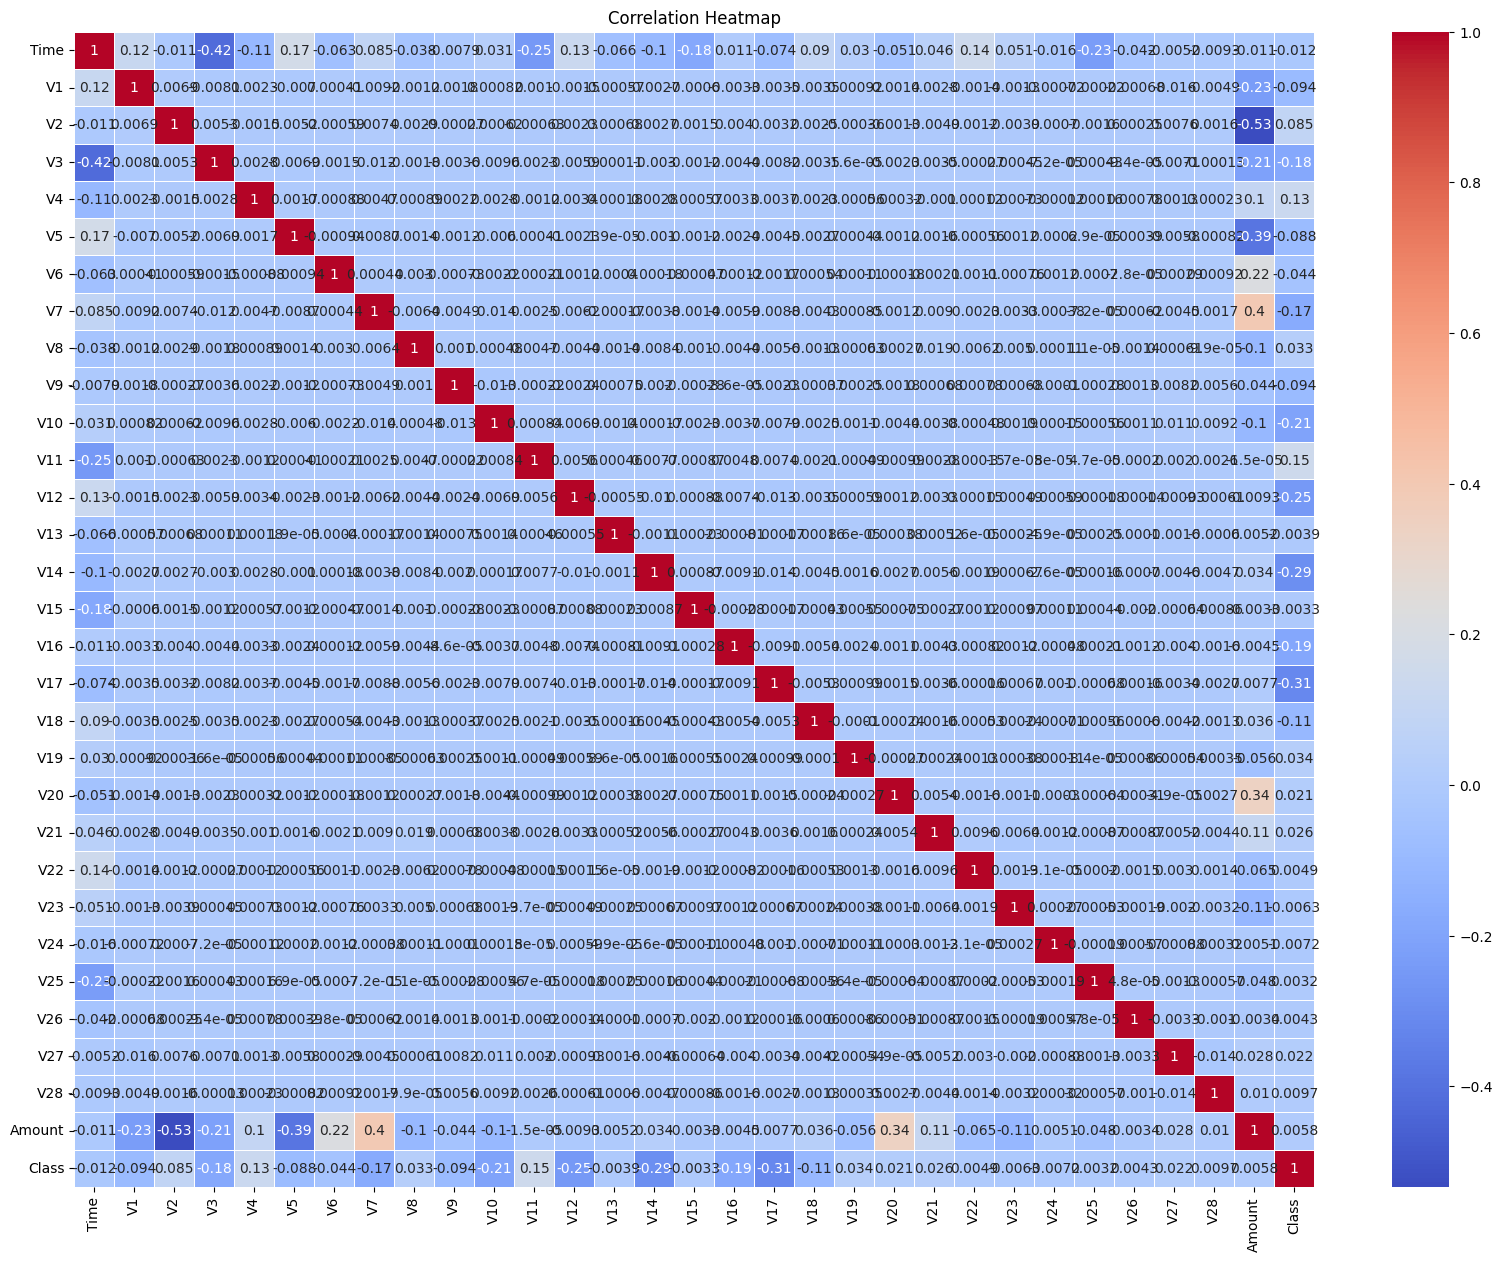

In [34]:
corr = df.corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr, cmap="coolwarm", annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

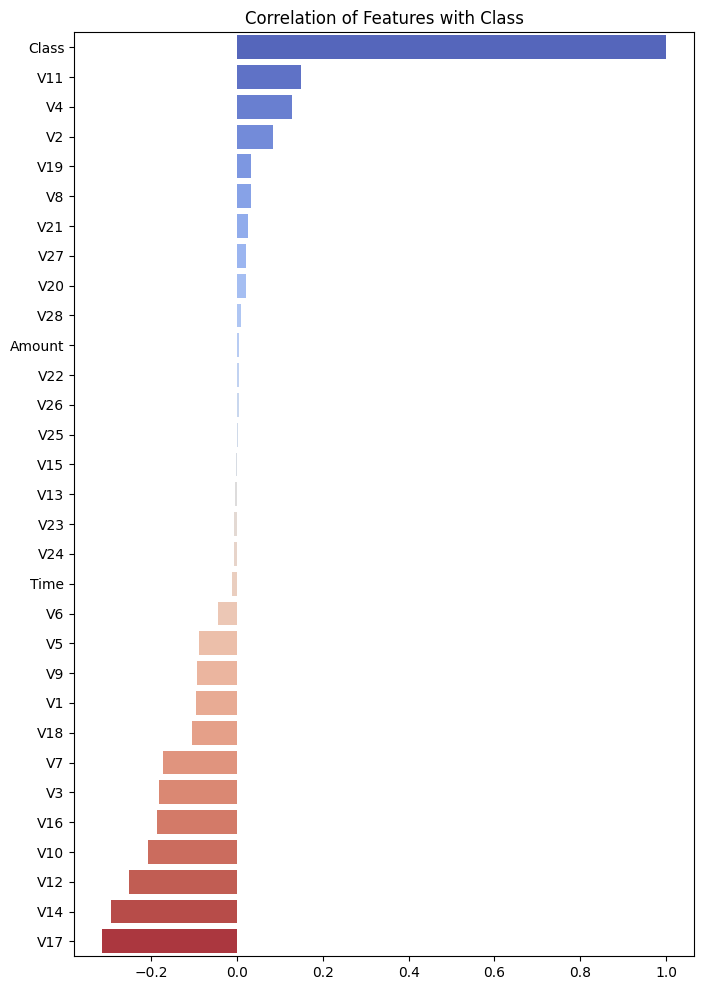

In [35]:
class_corr = corr["Class"].sort_values(ascending=False)

plt.figure(figsize=(8,12))
sns.barplot(x=class_corr.values, y=class_corr.index, palette="coolwarm")
plt.title("Correlation of Features with Class")
plt.show()

# Now Data Is not Balance I will Solve This By OverSampling

### Define X feature and Y Target 

In [36]:
X = df.drop("Class", axis=1)
y = df["Class"]

## Split Data To Train and Test 

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Resampling(Over Sample)

In [38]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [39]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_res.value_counts())

Before SMOTE: Class
0    226602
1       378
Name: count, dtype: int64
After SMOTE: Class
0    226602
1    226602
Name: count, dtype: int64


# Modeling

# Logistics Regression 

#### Call Model

In [40]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)


### Train Model   

In [41]:
log_reg.fit(X_res, y_res)


LogisticRegression(max_iter=1000, random_state=42)

### Test 

In [42]:
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]

## Evaluation 

In [43]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [44]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


ROC-AUC Score: 0.9625698993560758


## Random Forest 

### Call & Train

In [45]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_res, y_res)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Test 

In [46]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

### Evaluation 

In [47]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [48]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


ROC-AUC Score: 0.9693900511813327


# XGBoost

### Call and Train 

In [49]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

### Test

In [50]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

### Evalution

In [51]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.79      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [52]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))


ROC-AUC Score: 0.9699794401362358


### Hyperpramter Tuning for Xgboost

In [53]:
from sklearn.model_selection import RandomizedSearchCV


In [54]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [55]:
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=3, verbose=2, n_jobs=-1, random_state=42
)


In [56]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                           num_parallel_tree=None,
                                           random_state=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [57]:
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Score: 0.9838878928063931


# Train With this Parameters

In [58]:
best_xgb = XGBClassifier(
    subsample=0.6,
    reg_lambda=1.5,
    reg_alpha=0.01,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=1.0,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

best_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

### Test 

In [59]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

### Evaluation 

In [60]:
print("XGBoost (Tuned) Classification Report:\n")
print(classification_report(y_test, y_pred))

XGBoost (Tuned) Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.75      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [61]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9786342787649961


# Compare 

                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.999489   0.934211  0.747368  0.830409  0.978634
1        Random Forest  0.999489   0.912500  0.768421  0.834286  0.969390
2              XGBoost  0.999154   0.728155  0.789474  0.757576  0.969979
3        XGBoost Tuned  0.999489   0.934211  0.747368  0.830409  0.978634


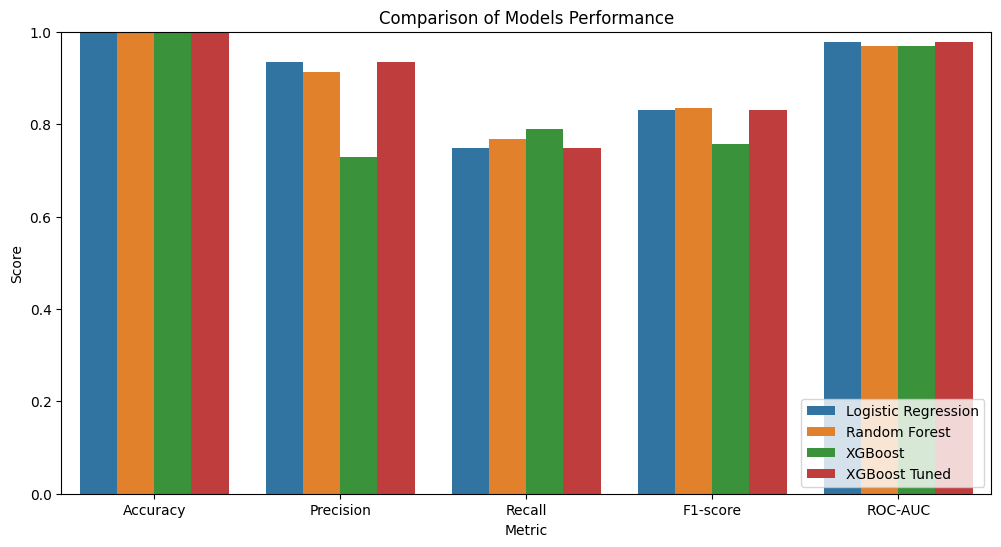

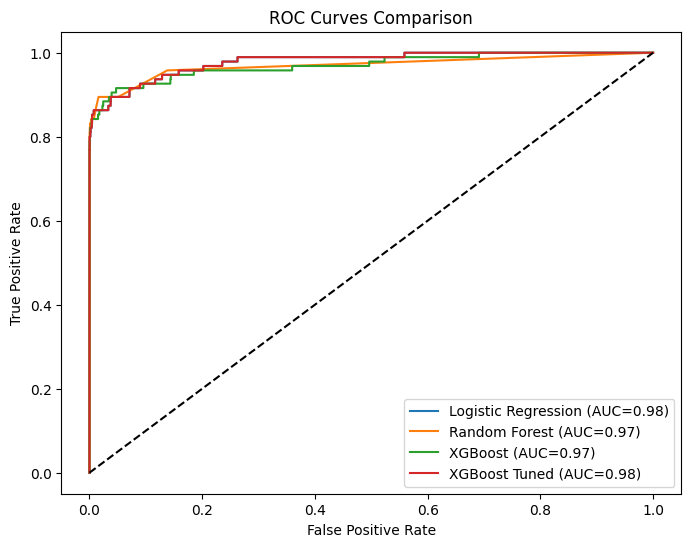

In [62]:
models = {
    "Logistic Regression": (y_test, y_pred, y_prob),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf),
    "XGBoost": (y_test, y_pred_xgb, y_prob_xgb),
    "XGBoost Tuned": (y_test, y_pred, y_prob)
}

results = []

for name, (yt, yp, ypr) in models.items():
    report = classification_report(yt, yp, output_dict=True)
    auc = roc_auc_score(yt, ypr)
    acc = accuracy_score(yt, yp)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": auc
    })

df_results = pd.DataFrame(results)
print(df_results)

metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

plt.figure(figsize=(12, 6))
df_melted = df_results.melt(id_vars="Model", value_vars=metrics, 
                            var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model")
plt.title("Comparison of Models Performance")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

# -------------------------------
# 3- رسم ROC Curves
# -------------------------------
plt.figure(figsize=(8, 6))

for name, (yt, yp, ypr) in models.items():
    fpr, tpr, _ = roc_curve(yt, ypr)
    auc = roc_auc_score(yt, ypr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # خط التوزيع العشوائي
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


# Save Model

In [63]:
import joblib
joblib.dump(best_xgb, "best_model.pkl")
print("✅ Best model saved as best_model.pkl")


✅ Best model saved as best_model.pkl


# Deploy Model 

In [64]:
import gradio as gr


In [65]:
model = joblib.load("/kaggle/working/best_model.pkl")


In [66]:


feature_columns = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                   'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18',
                   'V19', 'V20','V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
                   'V28', 'Amount']

def predict_model(*features):
    data = pd.DataFrame([features], columns=feature_columns)
    prediction = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]
    return int(prediction), float(prob)  

inputs = [gr.Number(label=col) for col in feature_columns]

iface = gr.Interface(
    fn=predict_model,
    inputs=inputs,
    outputs=[gr.Label(label="Prediction"), gr.Number(label="Probability of Fraud")],
    title="Fraud Detection Model",
    description="Enter transaction features to get prediction from the best model."
)

iface.launch()


* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://9edc02d06ca3ed5ae7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
